<a href="https://colab.research.google.com/github/rg5139/GamerPsycheAnalytics/blob/main/Hypothesis_Testing%20-%20Manasa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###FILE IMPORTS

##Schema for building results table

In [ ]:
# ----------------------------
# A) Recommended schema for building table of results
# ----------------------------
# results.csv columns:
# hypothesis_id   (e.g., "H1")
# hypothesis_name (short label)
# method          (e.g., "OLS", "Stratified", "Mediation", "PSM/IPW")
# outcome         ("GAD_T", "SWL_T", "SPIN_T_imputed")
# effect_label    (e.g., "league_score", "whyplay_winning", "T_strangers", etc.)
# coef            (float)
# p_value         (float)
# expected_dir    (+1 or -1)  # +1 means hypothesized increase; -1 means hypothesized decrease
# n              (optional)
# notes          (optional)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import ExtraTreesRegressor
from scipy import stats
import os

from datetime import datetime
from sklearn.impute import SimpleImputer
import chardet
import missingno as msno
# from sklearn.feature_extraction.text import Tfigamers_csvVectorizer
from sklearn.cluster import KMeans
from datetime import datetime
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from matplotlib.ticker import MaxNLocator

In [ ]:
# Reading the cleaned dataset
fileName = '/content/cleaned_gamers_dataset.csv'
with open(fileName, 'rb') as f:
        raw_data = f.read(10000) # Read a sample of the file
        result = chardet.detect(raw_data)
        file_encoding = result['encoding']

result_rows = []

gamers_csv = pd.read_csv(fileName,
                         encoding=file_encoding,
                         engine='python',
                         keep_default_na=False)
pd.set_option('display.max_columns', None)
gamers_csv

,S. No.,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GADE,SWL1,SWL2,SWL3,SWL4,SWL5,Hours,earnings,earnings_cluster,earnings_subcluster,whyplay,streams,Narcissism,Age,Degree,GAD_T,SWL_T,Residence_ISO3,Birthplace_ISO3,GADE_encoded,Game_encoded,Platform_encoded,whyplay_winning,whyplay_improving,whyplay_relaxing,whyplay_having_fun,whyplay_combined,whyplay_novel,whyplay_novel_cluster,lol_rank_num,sc2_rank_num,counterstrike_rank_num,hearth_rank_num,skyrim_rank_num,wow_rank_num,destiny_rank_num,diablo3_rank_num,hots_rank_num,gw2_rank_num,other_rank_num,avg_rank_score,avg_rank_score_scaled,max_rank_score,SPIN1_imputed,SPIN2_imputed,SPIN3_imputed,SPIN4_imputed,SPIN5_imputed,SPIN6_imputed,SPIN7_imputed,SPIN8_imputed,SPIN9_imputed,SPIN10_imputed,SPIN11_imputed,SPIN12_imputed,SPIN13_imputed,SPIN14_imputed,SPIN15_imputed,SPIN16_imputed,SPIN17_imputed,SPIN_T_imputed,Gender_encoded,Work_encoded,Degree_original,Degree_encoded,Playstyle_enum,Birthplace_ISO3_original,Birthplace_ISO3_ISO3,Residence_ISO3_original,Residence_ISO3_ISO3,Birthplace_ISO3_Numeric,Residence_ISO3_Numeric
0,1,0,0,0,0,1,0,0,Not difficult at all,3,5,5,5,5,15,I play for fun,0,0,having fun,0,1,25,Bachelor (or equivalent),1,23,USA,USA,0,1,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,5,2,0,Bachelor (or equivalent),2,1,USA,USA,USA,USA,840,840
1,2,1,2,2,2,0,1,0,Somewhat difficult,3,5,2,5,1,8,I play for fun,0,0,having fun,2,1,41,Bachelor (or equivalent),8,16,USA,USA,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,2,1,1,3,2,3,1,3,4,0,3,0,1,3,3,1,2,33,2,0,Bachelor (or equivalent),2,3,USA,USA,USA,USA,840,840
2,3,0,2,2,0,0,3,1,Not difficult at all,2,6,5,2,2,0,I play for fun,0,0,having fun,0,4,32,Bachelor (or equivalent),8,17,DEU,DEU,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,1,0,1,2,3,4,2,1,0,1,1,3,0,2,4,4,2,31,1,1,Bachelor (or equivalent),2,1,DEU,DEU,DEU,DEU,276,276
3,4,0,0,0,0,0,0,0,Not difficult at all,2,5,5,3,2,20,I play for fun,0,0,improving,5,2,28,Bachelor (or equivalent),0,17,USA,USA,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,2,0,0,1,3,0,0,0,0,0,1,3,0,0,1,0,0,11,2,1,Bachelor (or equivalent),2,4,USA,USA,USA,USA,840,840
4,5,2,1,2,2,2,3,2,Very difficult,2,2,4,5,1,20,I play for fun,0,0,having fun,1,1,19,High school diploma (or equivalent),14,14,KOR,USA,2,0,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,2,0,0,0,1,0,0,4,2,0,1,0,0,0,0,3,0,13,2,1,High school diploma (or equivalent),1,3,USA,USA,KOR,KOR,840,410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13402,14246,1,0,0,1,0,1,1,Not difficult at all,6,6,5,5,6,40,I play for fun,0,0,improving,10,3,22,Master (or equivalent),4,28,FRA,FRA,0,0,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,1,1,1,2,1,0,0,0,0,0,0,0,0,0,1,0,0,7,2,3,Master (or equivalent),3,3,FRA,FRA,FRA,FRA,250,250
13403,14247,3,3,3,3,2,3,3,Extremely difficult,5,5,5,4,4,20,I play for fun,0,0,winning,20,2,20,High school diploma (or equivalent),20,23,USA,USA,3,3,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,1,2,2,0,1,3,3,2,1,4,0,2,2,1,0,1,25,1,3,High school diploma (or equivalent),1,3,USA,USA,USA,USA,840,840
13404,14248,0,0,0,0,0,0,0,Not difficult at all,6,6,7,7,6,20,I play for fun,0,0,having fun,14,2,19,High school diploma (or equivalent),0,32,NOR,NOR,0,4,1,0,0,0,0,0,1,0,0,6,0,0,0,0,0,0,0,0,0,6.0,1,6,0,1,0,2,0,1,0,2,0,1,1,1,0,1,0,0,0,10,2,3,High school diploma (or equivalent),1,5,NOR,NOR,NOR,NOR,578,578
13405,14249,3,2,1,3,0,1,3,Somewhat difficult,2,6,3,2,3,5,I play for fun,0,0,having fun,0,2,18,High school diploma (or equivalent),13,16,CAN,CAN,1,0,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,1,3,2,3,4,1,3,4,1,3,1,0,3,2,0,1,32,1,2,High school diploma (or equivalent),1,1,CAN,CAN,CAN,CAN,124,124


##**PSYCHOGRAPHIC AXES**

###**HYPOTHESIS 1: League Status and Anxiety**
###*Players who participate in higher competitive league tiers will show higher GAD_T and lower SWL_T, due to pressure and performance stress*
###Status: waiting on Riya to provide modified avg_rank_score for league that will map the different range across games to a common one before computing average score

In [ ]:
# ==============================================================================
# HYPOTHESIS 1: Higher League ranking vs. high GAD_T and low SWL_T
# ==============================================================================

# -----------------------a) variable readiness----------------------------------
print("Shape before numeric coercion:", gamers_csv.shape)

key_cols = ["avg_rank_score_scaled", "GAD_T", "SWL_T", "Hours", "Narcissism", "Age",
              "whyplay_relaxing", "whyplay_having_fun"]
# ensure columns have no NA values and numeric types (spot checks)
gamers_csv[key_cols] = gamers_csv[key_cols].apply(pd.to_numeric, errors="coerce")


gamers_csv = gamers_csv.dropna(subset=["avg_rank_score_scaled", "GAD_T", "SWL_T"])
print("Shape after numeric coercion:", gamers_csv.shape)



Shape before numeric coercion: (13407, 80)
Shape after numeric coercion: (13407, 80)



=== Spearman Correlations with league_score ===
GAD_T: Spearman r=-0.005, p=0.582
SWL_T: Spearman r=-0.010, p=0.2644


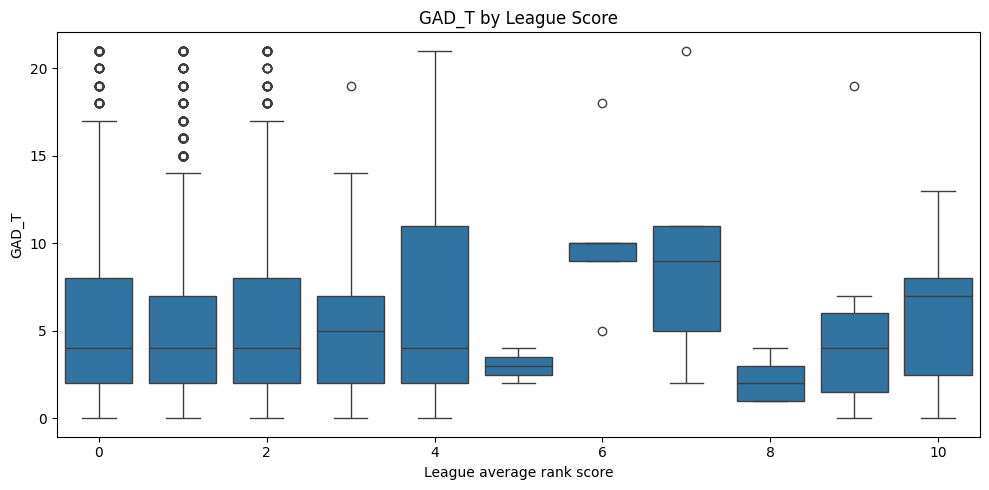

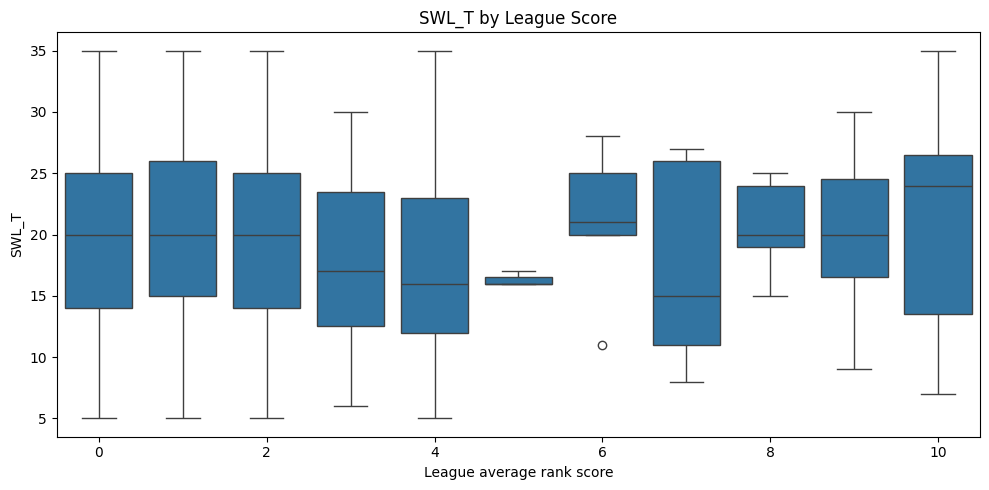

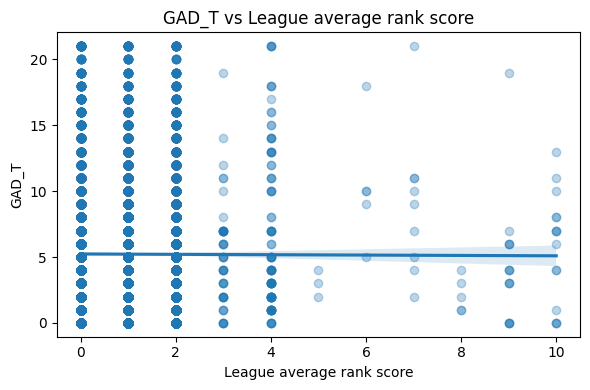

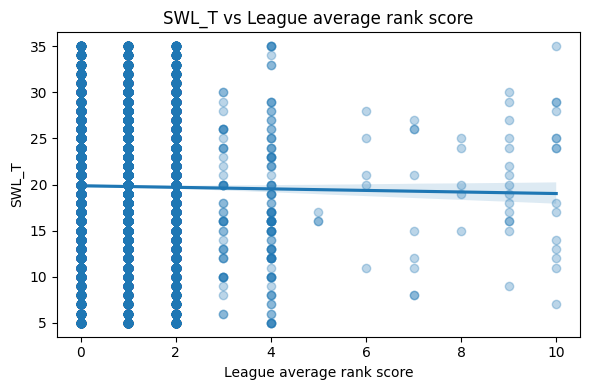

In [ ]:
# -----------------------b) EDA for correlations--------------------------------
print("\n=== Spearman Correlations with league_score ===")
for outcome in ["GAD_T", "SWL_T"]:
    spearman_r, spearman_p = stats.spearmanr(gamers_csv["avg_rank_score_scaled"], gamers_csv[outcome])
    print(f"{outcome}: Spearman r={spearman_r:.3f}, p={spearman_p:.4g}")

# Boxplots: GAD_T & SWL_T by league_score
# (treated as categorical for visualization)
plt.figure(figsize=(10, 5))
sns.boxplot(x="avg_rank_score_scaled", y="GAD_T", data=gamers_csv)
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title("GAD_T by League Score")
plt.xlabel("League average rank score")
plt.ylabel("GAD_T")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x="avg_rank_score_scaled", y="SWL_T", data=gamers_csv)
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title("SWL_T by League Score")
plt.xlabel("League average rank score")
plt.ylabel("SWL_T")
plt.tight_layout()
plt.show()

# Scatter with regression line
for outcome in ["GAD_T", "SWL_T"]:
    plt.figure(figsize=(6, 4))
    sns.regplot(x="avg_rank_score_scaled", y=outcome, data=gamers_csv, scatter_kws={"alpha": 0.3})
    plt.title(f"{outcome} vs League average rank score")
    plt.xlabel("League average rank score")
    plt.tight_layout()
    plt.show()




In [ ]:

# -----------------------c) Baseline Simple Regressions-------------------------
# Model 1: GAD_T ~ league_score
model1 = smf.ols("GAD_T ~ avg_rank_score_scaled", data=gamers_csv).fit()
#print("\n=== Baseline Model 1: GAD_T ~ league_score ===")
print(model1.summary())

# Model 2: SWL_T ~ league_score
model2 = smf.ols("SWL_T ~ avg_rank_score_scaled", data=gamers_csv).fit()
#print("\n=== Baseline Model 2: SWL_T ~ league_score ===")
print(model2.summary())

# Appending results to a list
result_rows.append(dict(hypothesis_id="H1", method="Baseline OLS", outcome="GAD_T",
                          effect_label="Average League Rank Score",
                          coef=float(model1.params["avg_rank_score_scaled"]),
                          p_value=float(model1.pvalues["avg_rank_score_scaled"]),
                          expected_dir= +1 if float(model1.params["avg_rank_score_scaled"]) > 0 else -1))

result_rows.append(dict(hypothesis_id="H1", method="Baseline OLS", outcome="SWL_T",
                          effect_label="Average League Rank Score",
                          coef=float(model2.params["avg_rank_score_scaled"]),
                          p_value=float(model2.pvalues["avg_rank_score_scaled"]),
                          expected_dir= +1 if float(model2.params["avg_rank_score_scaled"]) > 0 else -1))

                            OLS Regression Results                            
Dep. Variable:                  GAD_T   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.1026
Date:                Sat, 31 Jan 2026   Prob (F-statistic):              0.749
Time:                        19:24:20   Log-Likelihood:                -39811.
No. Observations:               13407   AIC:                         7.963e+04
Df Residuals:                   13405   BIC:                         7.964e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 5.23

In [ ]:
result_rows

[{'hypothesis_id': 'H1',
  'method': 'Baseline OLS',
  'outcome': 'GAD_T',
  'effect_label': 'Average League Rank Score',
  'coef': -0.013972904495867683,
  'p_value': 0.7487679673779266,
  'expected_dir': -1},
 {'hypothesis_id': 'H1',
  'method': 'Baseline OLS',
  'outcome': 'SWL_T',
  'effect_label': 'Average League Rank Score',
  'coef': -0.0843692987330817,
  'p_value': 0.2074773777756508,
  'expected_dir': -1}]

In [ ]:

# -----------------------d) Controlled Multivariate Regressions---------------
controls = (
    "Hours + Age + "
    "C(Narcissism) + "
    "Gender_encoded + Playstyle_enum + Game_encoded + Platform_encoded + "
    "whyplay_having_fun + whyplay_winning + whyplay_improving + "
    "whyplay_relaxing"
)

# Model 3: GAD_T ~ league_score + controls
formula3 = f"GAD_T ~ avg_rank_score_scaled + {controls}"
model3 = smf.ols(formula3, data=gamers_csv).fit()
#print("\n=== Controlled Model 3: GAD_T ~ league_score + controls ===")
print(model3.summary())

# Model 4: SWL_T ~ league_score + controls
formula4 = f"SWL_T ~ avg_rank_score_scaled + {controls}"
model4 = smf.ols(formula4, data=gamers_csv).fit()
#print("\n=== Controlled Model 4: SWL_T ~ league_score + controls ===")
print(model4.summary())

# Appending results to a list
result_rows.append(dict(hypothesis_id="H1", method="Controlled OLS", outcome="GAD_T",
                          effect_label="Average League Rank Score",
                          coef=float(model3.params["avg_rank_score_scaled"]),
                          p_value=float(model3.pvalues["avg_rank_score_scaled"]),
                          expected_dir= +1 if float(model3.params["avg_rank_score_scaled"]) > 0 else -1))

result_rows.append(dict(hypothesis_id="H1", method="Controlled OLS", outcome="SWL_T",
                          effect_label="Average League Rank Score",
                          coef=float(model4.params["avg_rank_score_scaled"]),
                          p_value=float(model4.pvalues["avg_rank_score_scaled"]),
                          expected_dir= +1 if float(model4.params["avg_rank_score_scaled"]) > 0 else -1))

                            OLS Regression Results                            
Dep. Variable:                  GAD_T   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     45.81
Date:                Sat, 31 Jan 2026   Prob (F-statistic):          1.09e-124
Time:                        19:24:50   Log-Likelihood:                -39391.
No. Observations:               13377   AIC:                         7.881e+04
Df Residuals:                   13362   BIC:                         7.893e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                11.96

In [ ]:
result_rows

[{'hypothesis_id': 'H1',
  'method': 'Baseline OLS',
  'outcome': 'GAD_T',
  'effect_label': 'Average League Rank Score',
  'coef': -0.013972904495867683,
  'p_value': 0.7487679673779266,
  'expected_dir': -1},
 {'hypothesis_id': 'H1',
  'method': 'Baseline OLS',
  'outcome': 'SWL_T',
  'effect_label': 'Average League Rank Score',
  'coef': -0.0843692987330817,
  'p_value': 0.2074773777756508,
  'expected_dir': -1},
 {'hypothesis_id': 'H1',
  'method': 'Controlled OLS',
  'outcome': 'GAD_T',
  'effect_label': 'Average League Rank Score',
  'coef': -0.025400251758607974,
  'p_value': 0.5673810361636988,
  'expected_dir': -1},
 {'hypothesis_id': 'H1',
  'method': 'Controlled OLS',
  'outcome': 'SWL_T',
  'effect_label': 'Average League Rank Score',
  'coef': -0.03927805540383047,
  'p_value': 0.5687713022588734,
  'expected_dir': -1},
 {'hypothesis_id': 'H1',
  'method': 'Controlled OLS Nonlinear',
  'outcome': 'GAD_T',
  'effect_label': 'Average League Rank Score',
  'coef': -0.09721023

In [ ]:

# -----------------------e) Non-linear & Interaction Models---------------------

# Quadratic term for league_score (possible U-shape)
formula5 = f"GAD_T ~ avg_rank_score_scaled + I(avg_rank_score_scaled**2) + {controls}"
model5 = smf.ols(formula5, data=gamers_csv).fit()
#print("\n=== Model 5: GAD_T ~ avg_rank_score_scaled + avg_rank_score_scaled^2 + controls ===")
print(model5.summary())

formula6 = f"SWL_T ~ avg_rank_score_scaled + I(avg_rank_score_scaled**2) + {controls}"
model6 = smf.ols(formula6, data=gamers_csv).fit()
#print("\n=== Model 6: SWL_T ~ avg_rank_score_scaled + avg_rank_score_scaled^2 + controls ===")
print(model6.summary())

# Interaction with Hours (does high rank + high Hours amplify effects?)
formula7 = f"GAD_T ~ avg_rank_score_scaled * Hours + {controls.replace('Hours + ', '')}"
model7 = smf.ols(formula7, data=gamers_csv).fit()
#print("\n=== Model 7: GAD_T ~ avg_rank_score_scaled * Hours + controls (minus duplicate Hours) ===")
print(model7.summary())

formula8 = f"SWL_T ~ avg_rank_score_scaled * Hours + {controls.replace('Hours + ', '')}"
model8 = smf.ols(formula8, data=gamers_csv).fit()
#print("\n=== Model 8: SWL_T ~ avg_rank_score_scaled * Hours + controls (minus duplicate Hours) ===")
print(model8.summary())

# Appending results to a list
result_rows.append(dict(hypothesis_id="H1", method="Controlled OLS Nonlinear", outcome="GAD_T",
                          effect_label="Average League Rank Score",
                          coef=float(model5.params["avg_rank_score_scaled"]),
                          p_value=float(model5.pvalues["avg_rank_score_scaled"]),
                          expected_dir= +1 if float(model5.params["avg_rank_score_scaled"]) > 0 else -1))

result_rows.append(dict(hypothesis_id="H1", method="Controlled OLS Nonlinear", outcome="SWL_T",
                          effect_label="Average League Rank Score",
                          coef=float(model6.params["avg_rank_score_scaled"]),
                          p_value=float(model6.pvalues["avg_rank_score_scaled"]),
                          expected_dir= +1 if float(model6.params["avg_rank_score_scaled"]) > 0 else -1))

result_rows.append(dict(hypothesis_id="H1", method="Controlled OLS Interaction", outcome="GAD_T",
                          effect_label="Average League Rank Score",
                          coef=float(model7.params["avg_rank_score_scaled"]),
                          p_value=float(model7.pvalues["avg_rank_score_scaled"]),
                          expected_dir= +1 if float(model7.params["avg_rank_score_scaled"]) > 0 else -1))

result_rows.append(dict(hypothesis_id="H1", method="Controlled OLS Interaction", outcome="SWL_T",
                          effect_label="Average League Rank Score",
                          coef=float(model8.params["avg_rank_score_scaled"]),
                          p_value=float(model8.pvalues["avg_rank_score_scaled"]),
                          expected_dir= +1 if float(model8.params["avg_rank_score_scaled"]) > 0 else -1))

                            OLS Regression Results                            
Dep. Variable:                  GAD_T   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     42.88
Date:                Sat, 31 Jan 2026   Prob (F-statistic):          3.00e-124
Time:                        19:52:28   Log-Likelihood:                -39390.
No. Observations:               13377   AIC:                         7.881e+04
Df Residuals:                   13361   BIC:                         7.893e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [ ]:
results = pd.DataFrame(result_rows)


results["p_value"] = results["p_value"].astype(float)
results["coef"] = results["coef"].astype(float)
results["expected_dir"] = results["expected_dir"].astype(int)

# Helpful derived fields
results["sig"] = results["p_value"] < 0.05
results["direction_ok"] = np.sign(results["coef"]) == np.sign(results["expected_dir"])
results["supports_hypothesis"] = results["sig"] & results["direction_ok"]
results.head(20)

new_names = {
    'hypothesis_id': 'Hypothesis ID',
    'method': 'Statistical Method',
    'outcome': 'Outcome',
    'effect_label': 'Dependent Variable',
    'coef': 'Coefficient',
    'p_value': 'P-value',
    'expected_dir': 'Expected Direction',
    'sig': 'Statistical Significance',
    'supports_hypothesis': 'Supports Hypothesis'
}
results_filtered = results.drop(columns='direction_ok')
# Rename columns and save to CSV
results_filtered.rename(columns=new_names).to_csv('Hypothesis_1_results.csv', index=False)

###**HYPOTHESIS 2: Streaming Engagement and Well-being**
###*Players who watch or stream gaming content frequently will report lower GAD_T and lower SPIN_T, mediated by social belonging*
### Key insight: All four analysis methods show higher stream engagement is significantly associated with higher anxiety (GAD_T) and higher social phobia (SPIN_T), thus contradicting the hypothesis

In [ ]:
import pandas as pd
import numpy as np

import statsmodels.formula.api as smf
import statsmodels.api as sm

from sklearn.neighbors import NearestNeighbors

# =========================
# 0) Load + basic prep
# =========================
# Key columns for H2
OUTCOMES = ["GAD_T", "SPIN_T_imputed"]
TREAT_CONT = "streams"   # continuous streaming engagement
HOURS_COL = "Hours"

# Controls (tailored to this dataset)
# - Narcissism is ordinal 1–5 -> treat as categorical via C(Narcissism)
# - Encoded cols exist: Gender_encoded, Playstyle_enum, Platform_encoded, Game_encoded
controls = (
    "Hours + Age + C(Narcissism) + "
    "Gender_encoded + Playstyle_enum + Platform_encoded + Game_encoded + "
    "whyplay_winning + whyplay_improving + whyplay_relaxing + whyplay_having_fun"
)

# Keep only rows with essentials
needed_cols = [TREAT_CONT, "Hours", "Age", "Narcissism",
               "Gender_encoded", "Playstyle_enum", "Platform_encoded", "Game_encoded",
               "whyplay_winning", "whyplay_improving", "whyplay_relaxing", "whyplay_having_fun"] + OUTCOMES
# There are 30 rows that have NA values in the hours column
gamers_csv = gamers_csv.dropna(subset=[c for c in needed_cols if c in gamers_csv.columns]).copy()

# Convert key cols to numeric (safe)
for c in [TREAT_CONT, "Hours", "Age", "Narcissism",
          "Gender_encoded", "Playstyle_enum", "Platform_encoded", "Game_encoded",
          "whyplay_winning", "whyplay_improving", "whyplay_relaxing", "whyplay_having_fun"] + OUTCOMES:
    if c in gamers_csv.columns:
        gamers_csv[c] = pd.to_numeric(gamers_csv[c], errors="coerce")

gamers_csv = gamers_csv.dropna(subset=[TREAT_CONT, "Hours", "Age", "Narcissism"] + OUTCOMES).copy()

# Often streams is skewed: log1p stabilizes without losing zeros
gamers_csv["streams_log1p"] = np.log1p(gamers_csv[TREAT_CONT])

print("Rows used:", len(gamers_csv))
print("Playstyle_enum values:", sorted(gamers_csv["Playstyle_enum"].dropna().unique().tolist()))
print("Streams summary:\n", gamers_csv[TREAT_CONT].describe())



Rows used: 13377
Playstyle_enum values: [1, 2, 3, 4, 5, 6, 7]
Streams summary:
 count    13377.000000
mean        10.545190
std         11.009989
min          0.000000
25%          4.000000
50%          8.000000
75%         15.000000
max        420.000000
Name: streams, dtype: float64


In [ ]:
hypo_2_results = []
# =========================
# 1) Method 1: Controlled regressions
# =========================
# Outcomes: GAD_T and SPIN_T_imputed
# Interpretation target: coefficient on streams_log1p (or streams)
def fit_ols(formula: str, data: pd.DataFrame):
    # Robust SE to handle heteroskedasticity common in survey data
    return smf.ols(formula, data=data).fit(cov_type="HC3")


m1_gad = fit_ols(f"GAD_T ~ streams_log1p + {controls}", gamers_csv)
print(m1_gad.summary())
m1_spin = fit_ols(f"SPIN_T_imputed ~ streams_log1p + {controls}", gamers_csv)
print(m1_spin.summary())


hypo_2_results.append(dict(hypothesis_id="H2", method="Controlled OLS", outcome="GAD_T",
                          effect_label="Streamed Hours",
                          coef=float(m1_gad.params["streams_log1p"]),
                          p_value=float(m1_gad.pvalues["streams_log1p"]),
                          expected_dir= -1))

hypo_2_results.append(dict(hypothesis_id="H2", method="Controlled OLS", outcome="SPIN_T",
                          effect_label="Streamed Hours",
                          coef=float(m1_spin.params["streams_log1p"]),
                          p_value=float(m1_spin.pvalues["streams_log1p"]),
                          expected_dir= -1))


                            OLS Regression Results                            
Dep. Variable:                  GAD_T   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     39.14
Date:                Sat, 31 Jan 2026   Prob (F-statistic):          1.13e-105
Time:                        20:08:45   Log-Likelihood:                -39369.
No. Observations:               13377   AIC:                         7.877e+04
Df Residuals:                   13362   BIC:                         7.888e+04
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             11.4684      0

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 14
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 14
  warnings.warn('covariance of constraints does not have full '


In [ ]:
hypo_2_results

[{'hypothesis_id': 'H2',
  'method': 'Controlled OLS',
  'outcome': 'GAD_T',
  'effect_label': 'Streamed Hours',
  'coef': 0.29676670652690956,
  'p_value': 4.5206827331062735e-06,
  'expected_dir': -1},
 {'hypothesis_id': 'H2',
  'method': 'Controlled OLS',
  'outcome': 'SPIN_T',
  'effect_label': 'Streamed Hours',
  'coef': 0.7949139062931257,
  'p_value': 1.564413468503945e-05,
  'expected_dir': -1}]

In [ ]:
# =========================
# 2) Method 2: Stratified models (heterogeneity)
# =========================
print("\n=================================")
print("METHOD 2: Stratified by play hours")
print("=================================")

# Simple split: low vs high hours (median split)
hours_med = gamers_csv[HOURS_COL].median()
gamers_csv["hours_group"] = np.where(gamers_csv[HOURS_COL] <= hours_med, "LowHours", "HighHours")

for grp in ["LowHours", "HighHours"]:
    sub = gamers_csv[gamers_csv["hours_group"] == grp].copy()
    mg = fit_ols(f"GAD_T ~ streams_log1p + {controls}", sub)
    #print(mg.summary())
    ms = fit_ols(f"SPIN_T_imputed ~ streams_log1p + {controls}", sub)
    print(f"\n[{grp}] n={len(sub)}")
    #print(ms.summary())
    print("  GAD streams_log1p coef, p:", float(mg.params["streams_log1p"]), float(mg.pvalues["streams_log1p"]))
    print("  SPIN streams_log1p coef, p:", float(ms.params["streams_log1p"]), float(ms.pvalues["streams_log1p"]))


hypo_2_results.append(dict(hypothesis_id="H2", method="Stratified by Hours", outcome="GAD_T",
                          effect_label="Streamed Hours",
                          coef=float(mg.params["streams_log1p"]),
                          p_value=float(mg.pvalues["streams_log1p"]),
                          expected_dir= -1))

hypo_2_results.append(dict(hypothesis_id="H2", method="Stratified by Hours", outcome="SPIN_T",
                          effect_label="Streamed Hours",
                          coef=float(ms.params["streams_log1p"]),
                          p_value=float(ms.pvalues["streams_log1p"]),
                          expected_dir= -1))


METHOD 2: Stratified by play hours

[LowHours] n=8294
  GAD streams_log1p coef, p: 0.19777741289537817 0.0005705983817952215
  SPIN streams_log1p coef, p: 0.725074236450174 1.0742810287963256e-05

[HighHours] n=5083
  GAD streams_log1p coef, p: 0.38134981478916136 1.765402805636769e-05
  SPIN streams_log1p coef, p: 0.6421849573767706 0.006015824224652521


In [ ]:
hypo_2_results

[{'hypothesis_id': 'H2',
  'method': 'Controlled OLS',
  'outcome': 'GAD_T',
  'effect_label': 'Streamed Hours',
  'coef': 0.29676670652690956,
  'p_value': 4.5206827331062735e-06,
  'expected_dir': -1},
 {'hypothesis_id': 'H2',
  'method': 'Controlled OLS',
  'outcome': 'SPIN_T',
  'effect_label': 'Streamed Hours',
  'coef': 0.7949139062931257,
  'p_value': 1.564413468503945e-05,
  'expected_dir': -1},
 {'hypothesis_id': 'H2',
  'method': 'Stratified by Hours',
  'outcome': 'GAD_T',
  'effect_label': 'Streamed Hours',
  'coef': 0.38134981478916136,
  'p_value': 1.765402805636769e-05,
  'expected_dir': -1},
 {'hypothesis_id': 'H2',
  'method': 'Stratified by Hours',
  'outcome': 'SPIN_T',
  'effect_label': 'Streamed Hours',
  'coef': 0.6421849573767706,
  'p_value': 0.006015824224652521,
  'expected_dir': -1}]

In [ ]:
# =========================
# 3) Method 3: Mediation (Streaming -> Social Belonging -> Well-being)
# =========================
print("\n====================================")
print("METHOD 3: Mediation via social proxy")
print("====================================")

# IMPORTANT:
# Dataset has no direct “belonging” scale.
# We create a proxy using Playstyle_enum.
# You must define which Playstyle_enum values are “social play”.
#
# To set these correctly, map Playstyle_enum back to your original playstyle labels.
# Social play likely includes values representing multiplayer/social play.
SOCIAL_PLAYSTYLE_VALUES = {3, 4, 5}  # different flavors of multiplayer mode
gamers_csv["social_belonging_proxy"] = gamers_csv["Playstyle_enum"].isin(SOCIAL_PLAYSTYLE_VALUES).astype(int)

print("social_belonging_proxy rate:", gamers_csv["social_belonging_proxy"].mean())

# a-path: streams -> belonging proxy
# Keep it simple + interpretable: linear probability model (LPM)
m_a = fit_ols(f"social_belonging_proxy ~ streams_log1p + {controls}", gamers_csv)

# b-path + c'-path: outcome ~ streams + belonging proxy + controls
m_med_gad = fit_ols(f"GAD_T ~ streams_log1p + social_belonging_proxy + {controls}", gamers_csv)
m_med_spin = fit_ols(f"SPIN_T_imputed ~ streams_log1p + social_belonging_proxy + {controls}", gamers_csv)

print("\n--- a-path: belonging ~ streams + controls ---")
print(m_a.summary())

print("\n--- Mediation model (GAD_T): outcome ~ streams + belonging + controls ---")
print(m_med_gad.summary())

print("\n--- Mediation model (SPIN_T): outcome ~ streams + belonging + controls ---")
print(m_med_spin.summary())


hypo_2_results.append(dict(hypothesis_id="H2", method="Mediation via social proxy", outcome="GAD_T",
                          effect_label="Streamed Hours",
                          coef=float(m_med_gad.params["streams_log1p"]),
                          p_value=float(m_med_gad.pvalues["streams_log1p"]),
                          expected_dir= -1))

hypo_2_results.append(dict(hypothesis_id="H2", method="Mediation via social proxy", outcome="SPIN_T",
                          effect_label="Streamed Hours",
                          coef=float(m_med_spin.params["streams_log1p"]),
                          p_value=float(m_med_spin.pvalues["streams_log1p"]),
                          expected_dir= -1))





METHOD 3: Mediation via social proxy
social_belonging_proxy rate: 0.9174702848172236

--- a-path: belonging ~ streams + controls ---
                              OLS Regression Results                              
Dep. Variable:     social_belonging_proxy   R-squared:                       0.152
Model:                                OLS   Adj. R-squared:                  0.151
Method:                     Least Squares   F-statistic:                     48.86
Date:                    Sat, 31 Jan 2026   Prob (F-statistic):          2.37e-133
Time:                            20:29:31   Log-Likelihood:                -614.12
No. Observations:                   13377   AIC:                             1258.
Df Residuals:                       13362   BIC:                             1371.
Df Model:                              14                                         
Covariance Type:                      HC3                                         
                         coef    std

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 14
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 16, but rank is 15
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in

In [ ]:
hypo_2_results

[{'hypothesis_id': 'H2',
  'method': 'Controlled OLS',
  'outcome': 'GAD_T',
  'effect_label': 'Streamed Hours',
  'coef': 0.29676670652690956,
  'p_value': 4.5206827331062735e-06,
  'expected_dir': -1},
 {'hypothesis_id': 'H2',
  'method': 'Controlled OLS',
  'outcome': 'SPIN_T',
  'effect_label': 'Streamed Hours',
  'coef': 0.7949139062931257,
  'p_value': 1.564413468503945e-05,
  'expected_dir': -1},
 {'hypothesis_id': 'H2',
  'method': 'Stratified by Hours',
  'outcome': 'GAD_T',
  'effect_label': 'Streamed Hours',
  'coef': 0.38134981478916136,
  'p_value': 1.765402805636769e-05,
  'expected_dir': -1},
 {'hypothesis_id': 'H2',
  'method': 'Stratified by Hours',
  'outcome': 'SPIN_T',
  'effect_label': 'Streamed Hours',
  'coef': 0.6421849573767706,
  'p_value': 0.006015824224652521,
  'expected_dir': -1},
 {'hypothesis_id': 'H2',
  'method': 'Mediation via social proxy',
  'outcome': 'GAD_T',
  'effect_label': 'Streamed Hours',
  'coef': 0.29524923164354555,
  'p_value': 5.1039168

In [ ]:
# =========================
# 4) Method 4: Propensity Score (PSM + IPW)
# =========================
print("\n=========================================")
print("METHOD 4: Propensity score (matching + IPW)")
print("=========================================")

# Convert continuous streaming into treatment (high vs low) based on median
treat_thresh = gamers_csv[TREAT_CONT].median()
gamers_csv["T_high_stream"] = (gamers_csv[TREAT_CONT] >= treat_thresh).astype(int)

# Propensity model: P(T=1 | covariates)
ps_formula = (
    "T_high_stream ~ Hours + Age + C(Narcissism) + "
    "Gender_encoded + Playstyle_enum + Platform_encoded + Game_encoded + "
    "whyplay_winning + whyplay_improving + whyplay_relaxing"
)

ps_mod = smf.logit(ps_formula, data=gamers_csv).fit(disp=False)
gamers_csv["pscore"] = ps_mod.predict(gamers_csv)

print("Treatment rate:", gamers_csv["T_high_stream"].mean())
print("Propensity score range:", float(gamers_csv["pscore"].min()), float(gamers_csv["pscore"].max()))

# ---- 4A) IPW (Inverse Probability Weighting) ATE ----
# Stabilized weights
p_t = gamers_csv["T_high_stream"].mean()
ps = np.clip(gamers_csv["pscore"].to_numpy(), 1e-3, 1 - 1e-3)
t = gamers_csv["T_high_stream"].to_numpy()

w = np.where(t == 1, p_t / ps, (1 - p_t) / (1 - ps))
gamers_csv["w_ipw"] = w

ipw_gad = smf.wls("GAD_T ~ T_high_stream", data=gamers_csv, weights=gamers_csv["w_ipw"]).fit(cov_type="HC3")
ipw_spin = smf.wls("SPIN_T_imputed ~ T_high_stream", data=gamers_csv, weights=gamers_csv["w_ipw"]).fit(cov_type="HC3")

print("\n--- IPW ATE (High vs Low stream) ---")
print("GAD_T: coef (T_high_stream), p =", float(ipw_gad.params["T_high_stream"]), float(ipw_gad.pvalues["T_high_stream"]))
print("SPIN : coef (T_high_stream), p =", float(ipw_spin.params["T_high_stream"]), float(ipw_spin.pvalues["T_high_stream"]))

# ---- 4B) Simple 1:1 nearest-neighbor matching on propensity score (ATT) ----
treated = gamers_csv[gamers_csv["T_high_stream"] == 1].copy()
control = gamers_csv[gamers_csv["T_high_stream"] == 0].copy()

# Nearest neighbor on pscore (with replacement for simplicity)
nbrs = NearestNeighbors(n_neighbors=1, algorithm="auto").fit(control[["pscore"]].to_numpy())
dist, idx = nbrs.kneighbors(treated[["pscore"]].to_numpy())

matched_control = control.iloc[idx.flatten()].copy()
matched_pairs = treated.reset_index(drop=True).copy()
matched_pairs["match_pscore"] = matched_control["pscore"].to_numpy()

# ATT estimates
att_gad = (matched_pairs["GAD_T"].to_numpy() - matched_control["GAD_T"].to_numpy()).mean()
att_spin = (matched_pairs["SPIN_T_imputed"].to_numpy() - matched_control["SPIN_T_imputed"].to_numpy()).mean()

print("\n--- PSM 1:1 Matching ATT (Treated - Matched Control) ---")
print("ATT GAD_T :", float(att_gad))
print("ATT SPIN  :", float(att_spin))

print("\nDONE.")

hypo_2_results.append(dict(hypothesis_id="H2", method="Propensity Score Matching", outcome="GAD_T",
                          effect_label="Streamed Hours",
                          coef=float(ipw_gad.params["T_high_stream"]),
                          p_value=float(ipw_gad.pvalues["T_high_stream"]),
                          expected_dir= -1))

hypo_2_results.append(dict(hypothesis_id="H2", method="Propensity Score Matching", outcome="SPIN_T",
                          effect_label="Streamed Hours",
                          coef=float(ipw_spin.params["T_high_stream"]),
                          p_value=float(ipw_spin.pvalues["T_high_stream"]),
                          expected_dir= -1))



METHOD 4: Propensity score (matching + IPW)
Treatment rate: 0.5265007101741795
Propensity score range: 0.26329095461021157 1.0

--- IPW ATE (High vs Low stream) ---
GAD_T: coef (T_high_stream), p = 0.4023264546235014 1.0192633728829288e-06
SPIN : coef (T_high_stream), p = 0.9992017032361918 2.1174282760372338e-05

--- PSM 1:1 Matching ATT (Treated - Matched Control) ---
ATT GAD_T : 0.5824222632400966
ATT SPIN  : 1.3029958824364618

DONE.


In [ ]:
results = pd.DataFrame(hypo_2_results)


results["p_value"] = results["p_value"].astype(float)
results["coef"] = results["coef"].astype(float)
results["expected_dir"] = results["expected_dir"].astype(int)

# Helpful derived fields
results["sig"] = results["p_value"] < 0.05
results["direction_ok"] = np.sign(results["coef"]) == np.sign(results["expected_dir"])
results["supports_hypothesis"] = results["sig"] & results["direction_ok"]
results.head(20)

new_names = {
    'hypothesis_id': 'Hypothesis ID',
    'method': 'Statistical Method',
    'outcome': 'Outcome',
    'effect_label': 'Dependent Variable',
    'coef': 'Coefficient',
    'p_value': 'P-value',
    'expected_dir': 'Expected Direction',
    'sig': 'Statistical Significance',
    'supports_hypothesis': 'Supports Hypothesis'
}
results_filtered = results.drop(columns='direction_ok')
# Rename columns and save to CSV
results_filtered.rename(columns=new_names).to_csv('Hypothesis_2_results.csv', index=False)

###**HYPOTHESIS 3: Narcissism and Life Satisfaction**
###*Gamers with higher narcissism showed lower SWL_T and higher SPIN_T reflecting external validation preference*
###Result: Narcissism significantly increased validation-oriented motivation (playing to win), and this motivation was strongly associated with lower SWL and higher SPIN; however, narcissism itself had no direct effect on either outcome once the mediator was included, indicating an indirect, behavior-mediated pathway rather than a direct effect.

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline

# =========================
# 0) Load + prep
# =========================

# Required columns
needed = [
    "Narcissism", "SWL_T", "SPIN_T_imputed",
    "Hours", "Age",
    "Gender_encoded", "Playstyle_enum", "Platform_encoded", "Game_encoded",
    "whyplay_winning", "whyplay_improving", "whyplay_relaxing"
]
gamers_csv = gamers_csv.dropna(subset=[c for c in needed if c in gamers_csv.columns]).copy()

# Ensure numeric types
for c in needed:
    if c in gamers_csv.columns:
        gamers_csv[c] = pd.to_numeric(gamers_csv[c], errors="coerce")
gamers_csv = gamers_csv.dropna(subset=["Narcissism", "SWL_T", "SPIN_T_imputed", "Hours", "Age"]).copy()

print("Rows used:", len(gamers_csv))
print("Narcissism unique:", sorted(gamers_csv["Narcissism"].unique().tolist()))

# Controls
controls = (
    "Hours + Age + Gender_encoded + Playstyle_enum + Platform_encoded + Game_encoded + "
    "whyplay_improving + whyplay_relaxing"
)





Rows used: 13377
Narcissism unique: [1, 2, 3, 4, 5]


In [ ]:
hypo_3_results = []

# =========================================================
# METHOD 1) Controlled regressions (core evidence)
# =========================================================
print("\n=========================")
print("METHOD 1: Controlled OLS")
print("=========================")

def fit_ols(formula: str, data: pd.DataFrame):
    # Robust SE (HC3) for survey-style data
    return smf.ols(formula, data=data).fit(cov_type="HC3")

# Treat Narcissism as categorical (nonlinear effect)
m1_swl = fit_ols(f"SWL_T ~ C(Narcissism) + {controls}", gamers_csv)
m1_spin = fit_ols(f"SPIN_T_imputed ~ C(Narcissism) + {controls}", gamers_csv)

print("\n--- SWL_T controlled regression: SWL_T ~ C(Narcissism) + controls ---")
print(m1_swl.summary())

print("\n--- SPIN_T controlled regression: SPIN_T ~ C(Narcissism) + controls ---")
print(m1_spin.summary())

hypo_3_results.append(dict(hypothesis_id="H3", method="Controlled OLS", outcome="SWL_T",
                          effect_label="Narcissism",
                          coef=float(m1_swl.params["C(Narcissism)[T.5]"]),
                          p_value=float(m1_swl.pvalues["C(Narcissism)[T.5]"]),
                          expected_dir= -1))

hypo_3_results.append(dict(hypothesis_id="H3", method="Controlled OLS", outcome="SPIN_T",
                          effect_label="Narcissism",
                          coef=float(m1_spin.params["C(Narcissism)[T.5]"]),
                          p_value=float(m1_spin.pvalues["C(Narcissism)[T.5]"]),
                          expected_dir= +1))


METHOD 1: Controlled OLS

--- SWL_T controlled regression: SWL_T ~ C(Narcissism) + controls ---
                            OLS Regression Results                            
Dep. Variable:                  SWL_T   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     15.58
Date:                Sat, 31 Jan 2026   Prob (F-statistic):           2.87e-33
Time:                        22:07:07   Log-Likelihood:                -45331.
No. Observations:               13377   AIC:                         9.069e+04
Df Residuals:                   13364   BIC:                         9.079e+04
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------

In [ ]:
hypo_3_results

[{'hypothesis_id': 'H3',
  'method': 'Controlled OLS',
  'outcome': 'SWL_T',
  'effect_label': 'Narcissism',
  'coef': -0.521907782263446,
  'p_value': 0.3760456944806415,
  'expected_dir': -1},
 {'hypothesis_id': 'H3',
  'method': 'Controlled OLS',
  'outcome': 'SPIN_T',
  'effect_label': 'Narcissism',
  'coef': -0.4022413572211557,
  'p_value': 0.6789602255257631,
  'expected_dir': 1}]

In [ ]:
# =========================================================
# METHOD 2) Stratified models (heterogeneity)
# =========================================================
print("\n=================================")
print("METHOD 2: Stratified by play hours")
print("=================================")

hours_med = gamers_csv["Hours"].median()
gamers_csv["hours_group"] = np.where(gamers_csv["Hours"] <= hours_med, "LowHours", "HighHours")

for grp in ["LowHours", "HighHours"]:
    sub = gamers_csv[gamers_csv["hours_group"] == grp].copy()
    mswl = fit_ols(f"SWL_T ~ Narcissism + {controls}", sub)
    print(mswl.summary())
    mspin = fit_ols(f"SPIN_T_imputed ~ Narcissism + {controls}", sub)
    print(mspin.summary())
    print(f"\n[{grp}] n={len(sub)}")
    print("  SWL: Narcissism coef, p =", float(mswl.params["Narcissism"]), float(mswl.pvalues["Narcissism"]))
    print("  SPIN: Narcissism coef, p =", float(mspin.params["Narcissism"]), float(mspin.pvalues["Narcissism"]))


hypo_3_results.append(dict(hypothesis_id="H3", method="Stratified by play hours", outcome="SWL_T",
                          effect_label="Narcissism",
                          coef=float(mswl.params["Narcissism"]),
                          p_value=float(mswl.pvalues["Narcissism"]),
                          expected_dir= -1))

hypo_3_results.append(dict(hypothesis_id="H3", method="Stratified by play hours", outcome="SPIN_T",
                          effect_label="Narcissism",
                          coef=float(mspin.params["Narcissism"]),
                          p_value=float(mspin.pvalues["Narcissism"]),
                          expected_dir= +1))


METHOD 2: Stratified by play hours
                            OLS Regression Results                            
Dep. Variable:                  SWL_T   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     14.26
Date:                Sat, 31 Jan 2026   Prob (F-statistic):           4.12e-23
Time:                        22:14:31   Log-Likelihood:                -27955.
No. Observations:                8294   AIC:                         5.593e+04
Df Residuals:                    8284   BIC:                         5.600e+04
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
In

In [ ]:
hypo_3_results

[{'hypothesis_id': 'H3',
  'method': 'Controlled OLS',
  'outcome': 'SWL_T',
  'effect_label': 'Narcissism',
  'coef': -0.521907782263446,
  'p_value': 0.3760456944806415,
  'expected_dir': -1},
 {'hypothesis_id': 'H3',
  'method': 'Controlled OLS',
  'outcome': 'SPIN_T',
  'effect_label': 'Narcissism',
  'coef': -0.4022413572211557,
  'p_value': 0.6789602255257631,
  'expected_dir': 1},
 {'hypothesis_id': 'H3',
  'method': 'Stratified by play hours',
  'outcome': 'SWL_T',
  'effect_label': 'Narcissism',
  'coef': 0.07920640031728163,
  'p_value': 0.42322549651298946,
  'expected_dir': -1},
 {'hypothesis_id': 'H3',
  'method': 'Stratified by play hours',
  'outcome': 'SPIN_T',
  'effect_label': 'Narcissism',
  'coef': -0.3871311852754008,
  'p_value': 0.03433820206840943,
  'expected_dir': 1}]

In [ ]:
# =========================================================
# METHOD 3) Mediation via “external validation dependence” proxy
# =========================================================
print("\n====================================")
print("METHOD 3: Mediation via validation proxy")
print("====================================")

# Proxy for external validation dependence:
# - primary: whyplay_winning (binary)
# - secondary: whyplay_improving (binary)
mediator = "whyplay_winning"

# a-path: Narcissism -> mediator
m_a = fit_ols(f"{mediator} ~ Narcissism + {controls}", gamers_csv)

# b + c' paths: outcomes ~ Narcissism + mediator + controls
m_med_swl = fit_ols(f"SWL_T ~ Narcissism + {mediator} + {controls}", gamers_csv)
m_med_spin = fit_ols(f"SPIN_T_imputed ~ Narcissism + {mediator} + {controls}", gamers_csv)

print("\n--- a-path: mediator ~ Narcissism + controls ---")
print(m_a.summary())

print("\n--- Mediation model (SWL_T): SWL_T ~ Narcissism + mediator + controls ---")
print(m_med_swl.summary())

print("\n--- Mediation model (SPIN_T): SPIN_T ~ Narcissism + mediator + controls ---")
print(m_med_spin.summary())

hypo_3_results.append(dict(hypothesis_id="H3", method="Mediation via validation proxy", outcome="whyplay_winning",
                          effect_label="Narcissism",
                          coef=float(m_a.params["Narcissism"]),
                          p_value=float(m_a.pvalues["Narcissism"]),
                          expected_dir= +1))

hypo_3_results.append(dict(hypothesis_id="H3", method="Mediation via validation proxy", outcome="SWL_T",
                          effect_label="Playing to Win",
                          coef=float(m_med_swl.params["whyplay_winning"]),
                          p_value=float(m_med_swl.pvalues["whyplay_winning"]),
                          expected_dir= -1))

hypo_3_results.append(dict(hypothesis_id="H3", method="Mediation via validation proxy", outcome="SPIN_T",
                          effect_label="Playing to Win",
                          coef=float(m_med_spin.params["whyplay_winning"]),
                          p_value=float(m_med_spin.pvalues["whyplay_winning"]),
                          expected_dir= +1))



METHOD 3: Mediation via validation proxy

--- a-path: mediator ~ Narcissism + controls ---
                            OLS Regression Results                            
Dep. Variable:        whyplay_winning   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     284.6
Date:                Sat, 31 Jan 2026   Prob (F-statistic):               0.00
Time:                        22:15:39   Log-Likelihood:                -4605.3
No. Observations:               13377   AIC:                             9231.
Df Residuals:                   13367   BIC:                             9306.
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------

In [ ]:
hypo_3_results

[{'hypothesis_id': 'H3',
  'method': 'Controlled OLS',
  'outcome': 'SWL_T',
  'effect_label': 'Narcissism',
  'coef': -0.521907782263446,
  'p_value': 0.3760456944806415,
  'expected_dir': -1},
 {'hypothesis_id': 'H3',
  'method': 'Controlled OLS',
  'outcome': 'SPIN_T',
  'effect_label': 'Narcissism',
  'coef': -0.4022413572211557,
  'p_value': 0.6789602255257631,
  'expected_dir': 1},
 {'hypothesis_id': 'H3',
  'method': 'Stratified by play hours',
  'outcome': 'SWL_T',
  'effect_label': 'Narcissism',
  'coef': 0.07920640031728163,
  'p_value': 0.42322549651298946,
  'expected_dir': -1},
 {'hypothesis_id': 'H3',
  'method': 'Stratified by play hours',
  'outcome': 'SPIN_T',
  'effect_label': 'Narcissism',
  'coef': -0.3871311852754008,
  'p_value': 0.03433820206840943,
  'expected_dir': 1},
 {'hypothesis_id': 'H3',
  'method': 'Mediation via validation proxy',
  'outcome': 'whyplay_winning',
  'effect_label': 'Narcissism',
  'coef': 0.04328806521732528,
  'p_value': 4.60646078978350

In [ ]:
# =========================================================
# METHOD 4) Propensity score: IPW ATE + 1:1 matching ATT
# =========================================================
print("\n=========================================")
print("METHOD 4: Propensity score (matching + IPW)")
print("=========================================")

# Treatment: "High narcissism" vs "Low"
# Simple + interpretable:
#   High = 4 or 5
#   Low  = 1–3
gamers_csv["T_high_narc"] = (gamers_csv["Narcissism"] >= 4).astype(int)

print("Treatment rate (High Narcissism):", gamers_csv["T_high_narc"].mean())

# Build propensity covariates (exclude Narcissism itself + exclude outcomes)
ps_covars = [
    "Hours", "Age",
    "Gender_encoded", "Playstyle_enum", "Platform_encoded", "Game_encoded",
    "whyplay_winning", "whyplay_improving", "whyplay_relaxing"
]
X = gamers_csv[ps_covars].copy()
y = gamers_csv["T_high_narc"].astype(int).copy()

# Drop constant columns (safety)
nunique = X.nunique(dropna=True)
bad_cols = nunique[nunique <= 1].index.tolist()
if bad_cols:
    print("Dropping constant columns from PS model:", bad_cols)
    X = X.drop(columns=bad_cols)

# Fit propensity model (regularized logistic regression to avoid singularity)
clf = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("logit", LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=3000))
])
clf.fit(X.values, y.values)
gamers_csv["pscore"] = clf.predict_proba(X.values)[:, 1]
gamers_csv["pscore"] = gamers_csv["pscore"].clip(1e-3, 1 - 1e-3)

print("Propensity score range:", float(gamers_csv["pscore"].min()), float(gamers_csv["pscore"].max()))

# ---- 4A) IPW ATE ----
p_t = gamers_csv["T_high_narc"].mean()
t = gamers_csv["T_high_narc"].to_numpy()
ps = gamers_csv["pscore"].to_numpy()

w = np.where(t == 1, p_t / ps, (1 - p_t) / (1 - ps))
gamers_csv["w_ipw"] = w

ipw_swl = smf.wls("SWL_T ~ T_high_narc", data=gamers_csv, weights=gamers_csv["w_ipw"]).fit(cov_type="HC3")
ipw_spin = smf.wls("SPIN_T_imputed ~ T_high_narc", data=gamers_csv, weights=gamers_csv["w_ipw"]).fit(cov_type="HC3")

print("\n--- IPW ATE (High vs Low Narcissism) ---")
print("SWL_T : coef (T_high_narc), p =", float(ipw_swl.params["T_high_narc"]), float(ipw_swl.pvalues["T_high_narc"]))
print("SPIN  : coef (T_high_narc), p =", float(ipw_spin.params["T_high_narc"]), float(ipw_spin.pvalues["T_high_narc"]))

# ---- 4B) 1:1 nearest-neighbor matching on pscore (ATT) ----
treated = gamers_csv[gamers_csv["T_high_narc"] == 1].copy()
control = gamers_csv[gamers_csv["T_high_narc"] == 0].copy()

nbrs = NearestNeighbors(n_neighbors=1, algorithm="auto").fit(control[["pscore"]].to_numpy())
dist, idx = nbrs.kneighbors(treated[["pscore"]].to_numpy())

matched_control = control.iloc[idx.flatten()].copy()

att_swl = (treated["SWL_T"].to_numpy() - matched_control["SWL_T"].to_numpy()).mean()
att_spin = (treated["SPIN_T_imputed"].to_numpy() - matched_control["SPIN_T_imputed"].to_numpy()).mean()

print("\n--- PSM 1:1 Matching ATT (High Narcissism - Matched Low Narcissism) ---")
print("ATT SWL_T :", float(att_swl))
print("ATT SPIN  :", float(att_spin))

print("\nDONE.")

hypo_3_results.append(dict(hypothesis_id="H3", method="Propensity score matching", outcome="SWL_T",
                          effect_label="Narcissism",
                          coef=float(ipw_swl.params["T_high_narc"]),
                          p_value=float(ipw_swl.pvalues["T_high_narc"]),
                          expected_dir= -1))

hypo_3_results.append(dict(hypothesis_id="H3", method="Propensity score matching", outcome="SPIN_T",
                          effect_label="Narcissism",
                          coef=float(ipw_spin.params["T_high_narc"]),
                          p_value=float(ipw_spin.pvalues["T_high_narc"]),
                          expected_dir= +1))


METHOD 4: Propensity score (matching + IPW)
Treatment rate (High Narcissism): 0.11018913059729386
Propensity score range: 0.03036499319286437 0.999

--- IPW ATE (High vs Low Narcissism) ---
SWL_T : coef (T_high_narc), p = -0.2362807675240427 0.28105706921047546
SPIN  : coef (T_high_narc), p = 0.3146911824108433 0.43494933602529084

--- PSM 1:1 Matching ATT (High Narcissism - Matched Low Narcissism) ---
ATT SWL_T : -0.5854816824966079
ATT SPIN  : 0.5149253731343284

DONE.


In [ ]:
hypo_3_results

[{'hypothesis_id': 'H3',
  'method': 'Controlled OLS',
  'outcome': 'SWL_T',
  'effect_label': 'Narcissism',
  'coef': -0.521907782263446,
  'p_value': 0.3760456944806415,
  'expected_dir': -1},
 {'hypothesis_id': 'H3',
  'method': 'Controlled OLS',
  'outcome': 'SPIN_T',
  'effect_label': 'Narcissism',
  'coef': -0.4022413572211557,
  'p_value': 0.6789602255257631,
  'expected_dir': 1},
 {'hypothesis_id': 'H3',
  'method': 'Stratified by play hours',
  'outcome': 'SWL_T',
  'effect_label': 'Narcissism',
  'coef': 0.07920640031728163,
  'p_value': 0.42322549651298946,
  'expected_dir': -1},
 {'hypothesis_id': 'H3',
  'method': 'Stratified by play hours',
  'outcome': 'SPIN_T',
  'effect_label': 'Narcissism',
  'coef': -0.3871311852754008,
  'p_value': 0.03433820206840943,
  'expected_dir': 1},
 {'hypothesis_id': 'H3',
  'method': 'Mediation via validation proxy',
  'outcome': 'whyplay_winning',
  'effect_label': 'Narcissism',
  'coef': 0.04328806521732528,
  'p_value': 4.60646078978350

In [ ]:
results = pd.DataFrame(hypo_3_results)


results["p_value"] = results["p_value"].astype(float)
results["coef"] = results["coef"].astype(float)
results["expected_dir"] = results["expected_dir"].astype(int)

# Helpful derived fields
results["sig"] = results["p_value"] < 0.05
results["direction_ok"] = np.sign(results["coef"]) == np.sign(results["expected_dir"])
results["supports_hypothesis"] = results["sig"] & results["direction_ok"]
results.head(20)

new_names = {
    'hypothesis_id': 'Hypothesis ID',
    'method': 'Statistical Method',
    'outcome': 'Outcome',
    'effect_label': 'Dependent Variable',
    'coef': 'Coefficient',
    'p_value': 'P-value',
    'expected_dir': 'Expected Direction',
    'sig': 'Statistical Significance',
    'supports_hypothesis': 'Supports Hypothesis'
}
results_filtered = results.drop(columns='direction_ok')
# Rename columns and save to CSV
results_filtered.rename(columns=new_names).to_csv('Hypothesis_3_results.csv', index=False)

###**HYPOTHESIS 4: Motivation (WhyPlay) & Anxiety**
###*Players high on escapism or avoidance motives (whyplay_relaxing) will exhibit higher GAD_T and lower SWL_T*
###Keypoint: Taken together, all four methods converge on the same conclusion: escapism is a maladaptive motivational profile associated with worse mental health outcomes. Its effects are direct rather than mediated by play intensity, persist across usage strata, and are concentrated among escapist players themselves rather than uniformly distributed across the population. The absence of strong population-average effects is consistent with escapism being a rare but high-risk coping strategy, rather than a normative gaming motive.

In [ ]:
# Hypothesis 4: Escapism/Avoidance Motives & Well-being
# H4: Players high on escapism/avoidance motives will exhibit higher GAD_T and lower SWL_T.


import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# =========================
# 0) Load + identify columns
# =========================
PATH = "/content/cleaned_gamers_dataset.csv"
gamers_csv = pd.read_csv(PATH)

print("Rows (raw):", len(gamers_csv))
print("Columns:", len(gamers_csv.columns))
# ---- Core mapping for H4
ESCAPISM = "whyplay_relaxing"  # proxy for escapism/avoidance in this dataset

OUTCOMES = ["GAD_T", "SWL_T"]

# ---- Common covariates (aligned with your earlier hypotheses)
# Narcissism is categorical (1–5)
# Encoded columns exist for gender, platform, game, playstyle
BASE_CONTROLS = [
    "Hours", "Age",
    "Gender_encoded", "Playstyle_enum", "Platform_encoded", "Game_encoded",
    "whyplay_winning", "whyplay_improving"
    # NOTE: we intentionally do NOT include whyplay_having_fun (it can be constant / collinear)
    # and we do NOT include whyplay_relaxing because it's the treatment/variable-of-interest here.
]

# Helper: drop missing required columns
required = [ESCAPISM] + OUTCOMES + ["Narcissism"] + BASE_CONTROLS
missing = [c for c in required if c not in gamers_csv.columns]
if missing:
    raise ValueError(f"Missing required columns in dataset: {missing}")

# Coerce to numeric where appropriate
for c in required:
    gamers_csv[c] = pd.to_numeric(gamers_csv[c], errors="coerce")

gamers_csv = gamers_csv.dropna(subset=required).copy()

# Ensure binary for escapism proxy (should already be one-hot)
gamers_csv[ESCAPISM] = gamers_csv[ESCAPISM].astype(int).clip(0, 1)

print("\nRows used:", len(gamers_csv))
print(f"{ESCAPISM} rate:", gamers_csv[ESCAPISM].mean())
print("Narcissism unique:", sorted(gamers_csv["Narcissism"].unique().tolist()))

def fit_ols(formula: str, data: pd.DataFrame):
    # Robust SE (HC3) like your previous work
    return smf.ols(formula, data=data).fit(cov_type="HC3")


# Build formula string for controls (Narcissism categorical + base controls)
controls_str = "C(Narcissism) + " + " + ".join(BASE_CONTROLS)




Rows (raw): 13407
Columns: 80

Rows used: 13377
whyplay_relaxing rate: 0.051581071989235255
Narcissism unique: [1, 2, 3, 4, 5]


In [ ]:
hypo_4_results = []

# =========================
# METHOD 1: Controlled OLS
# =========================
print("\n=========================")
print("METHOD 1: Controlled OLS")
print("=========================")

m1_gad = fit_ols(f"GAD_T ~ {ESCAPISM} + {controls_str}", gamers_csv)
m1_swl = fit_ols(f"SWL_T ~ {ESCAPISM} + {controls_str}", gamers_csv)

print(f"\n--- GAD_T ~ {ESCAPISM} + controls ---")
print(m1_gad.summary())

print(f"\n--- SWL_T ~ {ESCAPISM} + controls ---")
print(m1_swl.summary())

print("\nKey H4 coefficients (direction test):")
print("GAD_T: escapism coef, p =", float(m1_gad.params[ESCAPISM]), float(m1_gad.pvalues[ESCAPISM]))
print("SWL_T: escapism coef, p =", float(m1_swl.params[ESCAPISM]), float(m1_swl.pvalues[ESCAPISM]))

hypo_4_results.append(dict(hypothesis_id="H4", method="Controlled OLS", outcome="GAD_T",
                          effect_label="Escapism",
                          coef=float(m1_gad.params["whyplay_relaxing"]),
                          p_value=float(m1_gad.pvalues["whyplay_relaxing"]),
                          expected_dir= +1))

hypo_4_results.append(dict(hypothesis_id="H4", method="Controlled OLS", outcome="SWL_T",
                          effect_label="Escapism",
                          coef=float(m1_swl.params["whyplay_relaxing"]),
                          p_value=float(m1_swl.pvalues["whyplay_relaxing"]),
                          expected_dir= -1))



METHOD 1: Controlled OLS

--- GAD_T ~ whyplay_relaxing + controls ---
                            OLS Regression Results                            
Dep. Variable:                  GAD_T   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     38.66
Date:                Sat, 31 Jan 2026   Prob (F-statistic):           3.37e-97
Time:                        22:47:39   Log-Likelihood:                -39392.
No. Observations:               13377   AIC:                         7.881e+04
Df Residuals:                   13363   BIC:                         7.892e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

In [ ]:
hypo_4_results

[{'hypothesis_id': 'H4',
  'method': 'Controlled OLS',
  'outcome': 'GAD_T',
  'effect_label': 'Escapism',
  'coef': 1.3158587674087026,
  'p_value': 3.5762647103320847e-11,
  'expected_dir': 1},
 {'hypothesis_id': 'H4',
  'method': 'Controlled OLS',
  'outcome': 'SWL_T',
  'effect_label': 'Escapism',
  'coef': -1.2006842862515854,
  'p_value': 4.415686419454772e-05,
  'expected_dir': -1}]

In [ ]:
# =========================
# METHOD 2: Stratified by Hours
# =========================
print("\n=================================")
print("METHOD 2: Stratified by play hours")
print("=================================")

hours_med = gamers_csv["Hours"].median()
gamers_csv["hours_group"] = np.where(gamers_csv["Hours"] <= hours_med, "LowHours", "HighHours")

for grp in ["LowHours", "HighHours"]:
    sub = gamers_csv[gamers_csv["hours_group"] == grp].copy()
    mg = fit_ols(f"GAD_T ~ {ESCAPISM} + {controls_str}", sub)
    print(mg.summary())
    ms = fit_ols(f"SWL_T ~ {ESCAPISM} + {controls_str}", sub)
    print(ms.summary())
    print(f"\n[{grp}] n={len(sub)}")
    print("  GAD escapism coef, p:", float(mg.params[ESCAPISM]), float(mg.pvalues[ESCAPISM]))
    print("  SWL escapism coef, p:", float(ms.params[ESCAPISM]), float(ms.pvalues[ESCAPISM]))


hypo_4_results.append(dict(hypothesis_id="H4", method="Stratified by play hours", outcome="GAD_T",
                          effect_label="Escapism",
                          coef=float(mg.params["whyplay_relaxing"]),
                          p_value=float(mg.pvalues["whyplay_relaxing"]),
                          expected_dir= +1))

hypo_4_results.append(dict(hypothesis_id="H4", method="Stratified by play hours", outcome="SWL_T",
                          effect_label="Escapism",
                          coef=float(ms.params["whyplay_relaxing"]),
                          p_value=float(ms.pvalues["whyplay_relaxing"]),
                          expected_dir= -1))


METHOD 2: Stratified by play hours
                            OLS Regression Results                            
Dep. Variable:                  GAD_T   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     22.87
Date:                Sat, 31 Jan 2026   Prob (F-statistic):           9.60e-55
Time:                        22:54:12   Log-Likelihood:                -24139.
No. Observations:                8294   AIC:                         4.831e+04
Df Residuals:                    8280   BIC:                         4.840e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------


In [ ]:
hypo_4_results

[{'hypothesis_id': 'H4',
  'method': 'Controlled OLS',
  'outcome': 'GAD_T',
  'effect_label': 'Escapism',
  'coef': 1.3158587674087026,
  'p_value': 3.5762647103320847e-11,
  'expected_dir': 1},
 {'hypothesis_id': 'H4',
  'method': 'Controlled OLS',
  'outcome': 'SWL_T',
  'effect_label': 'Escapism',
  'coef': -1.2006842862515854,
  'p_value': 4.415686419454772e-05,
  'expected_dir': -1},
 {'hypothesis_id': 'H4',
  'method': 'Stratified by play hours',
  'outcome': 'GAD_T',
  'effect_label': 'Escapism',
  'coef': 1.3148095638249968,
  'p_value': 0.0002956856795129177,
  'expected_dir': 1},
 {'hypothesis_id': 'H4',
  'method': 'Stratified by play hours',
  'outcome': 'SWL_T',
  'effect_label': 'Escapism',
  'coef': -1.113953173456918,
  'p_value': 0.04297147267399815,
  'expected_dir': -1}]

In [ ]:
# =========================
# METHOD 3: Mediation (Hours as mediator)
# =========================
print("\n====================================")
print("METHOD 3: Mediation via Hours (escapism -> hours -> outcomes)")
print("====================================")

# a-path: Hours ~ escapism + controls (excluding Hours itself)
# Build controls without Hours for the mediator regression
BASE_CONTROLS_NO_HOURS = [c for c in BASE_CONTROLS if c != "Hours"]
controls_no_hours_str = "C(Narcissism) + " + " + ".join(BASE_CONTROLS_NO_HOURS)

m_a = fit_ols(f"Hours ~ {ESCAPISM} + {controls_no_hours_str}", gamers_csv)

# b + c' paths: Outcome ~ escapism + Hours + controls (Hours included)
m_med_gad = fit_ols(f"GAD_T ~ {ESCAPISM} + Hours + {controls_str}", gamers_csv)
m_med_swl = fit_ols(f"SWL_T ~ {ESCAPISM} + Hours + {controls_str}", gamers_csv)

print(f"\n--- a-path: Hours ~ {ESCAPISM} + controls(no Hours) ---")
print(m_a.summary())

print(f"\n--- Mediation outcome (GAD_T): GAD_T ~ {ESCAPISM} + Hours + controls ---")
print(m_med_gad.summary())

print(f"\n--- Mediation outcome (SWL_T): SWL_T ~ {ESCAPISM} + Hours + controls ---")
print(m_med_swl.summary())


hypo_4_results.append(dict(hypothesis_id="H4", method="Mediation via Hours", outcome="Hours",
                          effect_label="Escapism",
                          coef=float(m_a.params["whyplay_relaxing"]),
                          p_value=float(m_a.pvalues["whyplay_relaxing"]),
                          expected_dir= +1))

hypo_4_results.append(dict(hypothesis_id="H4", method="Mediation via Hours", outcome="GAD_T",
                          effect_label="Escapism",
                          coef=float(m_med_gad.params["whyplay_relaxing"]),
                          p_value=float(m_med_gad.pvalues["whyplay_relaxing"]),
                          expected_dir= +1))

hypo_4_results.append(dict(hypothesis_id="H4", method="Mediation via Hours", outcome="SWL_T",
                          effect_label="Escapism",
                          coef=float(m_med_swl.params["whyplay_relaxing"]),
                          p_value=float(m_med_swl.pvalues["whyplay_relaxing"]),
                          expected_dir= -1))


METHOD 3: Mediation via Hours (escapism -> hours -> outcomes)

--- a-path: Hours ~ whyplay_relaxing + controls(no Hours) ---
                            OLS Regression Results                            
Dep. Variable:                  Hours   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     25.50
Date:                Sat, 31 Jan 2026   Prob (F-statistic):           1.31e-57
Time:                        23:00:08   Log-Likelihood:                -75820.
No. Observations:               13377   AIC:                         1.517e+05
Df Residuals:                   13364   BIC:                         1.518e+05
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.97

In [ ]:
hypo_4_results

[{'hypothesis_id': 'H4',
  'method': 'Controlled OLS',
  'outcome': 'GAD_T',
  'effect_label': 'Escapism',
  'coef': 1.3158587674087026,
  'p_value': 3.5762647103320847e-11,
  'expected_dir': 1},
 {'hypothesis_id': 'H4',
  'method': 'Controlled OLS',
  'outcome': 'SWL_T',
  'effect_label': 'Escapism',
  'coef': -1.2006842862515854,
  'p_value': 4.415686419454772e-05,
  'expected_dir': -1},
 {'hypothesis_id': 'H4',
  'method': 'Stratified by play hours',
  'outcome': 'GAD_T',
  'effect_label': 'Escapism',
  'coef': 1.3148095638249968,
  'p_value': 0.0002956856795129177,
  'expected_dir': 1},
 {'hypothesis_id': 'H4',
  'method': 'Stratified by play hours',
  'outcome': 'SWL_T',
  'effect_label': 'Escapism',
  'coef': -1.113953173456918,
  'p_value': 0.04297147267399815,
  'expected_dir': -1},
 {'hypothesis_id': 'H4',
  'method': 'Mediation via Hours',
  'outcome': 'Hours',
  'effect_label': 'Escapism',
  'coef': -1.5684075881674955,
  'p_value': 0.11007131219706037,
  'expected_dir': 1},

In [ ]:
# =========================
# METHOD 4: Propensity score (IPW ATE + Matching ATT)
# =========================
print("\n=========================================")
print("METHOD 4: Propensity score (matching + IPW)")
print("=========================================")

# Treatment is escapism/avoidance motive indicator
gamers_csv["T_escapism"] = gamers_csv[ESCAPISM].astype(int)

print("Treatment rate (T_escapism=1):", gamers_csv["T_escapism"].mean())

# Covariates for propensity model: exclude outcome, exclude treatment, exclude mediator? (Hours can stay as a baseline covariate)
ps_covars = [
    "Hours", "Age",
    "Gender_encoded", "Playstyle_enum", "Platform_encoded", "Game_encoded",
    "whyplay_winning", "whyplay_improving",
    # include Narcissism as numeric covariate for balancing; alternatively create dummies
    "Narcissism"
]

X = gamers_csv[ps_covars].copy()
y = gamers_csv["T_escapism"].astype(int).copy()

# Drop constant columns (stability)
nunique = X.nunique(dropna=True)
bad_cols = nunique[nunique <= 1].index.tolist()
if bad_cols:
    print("Dropping constant columns from PS model:", bad_cols)
    X = X.drop(columns=bad_cols)

# Regularized logit to avoid singular matrix issues
clf = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("logit", LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=3000))
])
clf.fit(X.values, y.values)

gamers_csv["pscore"] = clf.predict_proba(X.values)[:, 1]
gamers_csv["pscore"] = gamers_csv["pscore"].clip(1e-3, 1 - 1e-3)

print("Propensity score range:", float(gamers_csv["pscore"].min()), float(gamers_csv["pscore"].max()))

# ---- 4A) IPW ATE ----
p_t = gamers_csv["T_escapism"].mean()
t = gamers_csv["T_escapism"].to_numpy()
ps = gamers_csv["pscore"].to_numpy()

w = np.where(t == 1, p_t / ps, (1 - p_t) / (1 - ps))
gamers_csv["w_ipw"] = w

ipw_gad = smf.wls("GAD_T ~ T_escapism", data=gamers_csv, weights=gamers_csv["w_ipw"]).fit(cov_type="HC3")
ipw_swl = smf.wls("SWL_T ~ T_escapism", data=gamers_csv, weights=gamers_csv["w_ipw"]).fit(cov_type="HC3")

print("\n--- IPW ATE (Escapism vs Non-escapism) ---")
print("GAD_T: coef (T_escapism), p =", float(ipw_gad.params["T_escapism"]), float(ipw_gad.pvalues["T_escapism"]))
print("SWL_T: coef (T_escapism), p =", float(ipw_swl.params["T_escapism"]), float(ipw_swl.pvalues["T_escapism"]))

# ---- 4B) 1:1 nearest-neighbor matching on pscore (ATT) ----
treated = gamers_csv[gamers_csv["T_escapism"] == 1].copy()
control = gamers_csv[gamers_csv["T_escapism"] == 0].copy()

nbrs = NearestNeighbors(n_neighbors=1, algorithm="auto").fit(control[["pscore"]].to_numpy())
dist, idx = nbrs.kneighbors(treated[["pscore"]].to_numpy())
matched_control = control.iloc[idx.flatten()].copy()

att_gad = (treated["GAD_T"].to_numpy() - matched_control["GAD_T"].to_numpy()).mean()
att_swl = (treated["SWL_T"].to_numpy() - matched_control["SWL_T"].to_numpy()).mean()

print("\n--- PSM 1:1 Matching ATT (Treated - Matched Control) ---")
print("ATT GAD_T :", float(att_gad))
print("ATT SWL_T :", float(att_swl))

print("\nDONE.")

hypo_4_results.append(dict(hypothesis_id="H4", method="Propensity score matching", outcome="GAD_T",
                          effect_label="Escapism",
                          coef=float(ipw_gad.params["T_escapism"]),
                          p_value=float(ipw_gad.pvalues["T_escapism"]),
                          expected_dir= +1))

hypo_4_results.append(dict(hypothesis_id="H4", method="Propensity score matching", outcome="SWL_T",
                          effect_label="Escapism",
                          coef=float(ipw_swl.params["T_escapism"]),
                          p_value=float(ipw_swl.pvalues["T_escapism"]),
                          expected_dir= -1))


METHOD 4: Propensity score (matching + IPW)
Treatment rate (T_escapism=1): 0.051581071989235255
Propensity score range: 0.001 0.32421037973470096

--- IPW ATE (Escapism vs Non-escapism) ---
GAD_T: coef (T_escapism), p = 0.40541056767187816 0.7351761998227268
SWL_T: coef (T_escapism), p = 0.7971779317858798 0.4904546169024093

--- PSM 1:1 Matching ATT (Treated - Matched Control) ---
ATT GAD_T : 1.4434782608695653
ATT SWL_T : -1.1144927536231883

DONE.


In [ ]:
hypo_4_results

[{'hypothesis_id': 'H4',
  'method': 'Controlled OLS',
  'outcome': 'GAD_T',
  'effect_label': 'Escapism',
  'coef': 1.3158587674087026,
  'p_value': 3.5762647103320847e-11,
  'expected_dir': 1},
 {'hypothesis_id': 'H4',
  'method': 'Controlled OLS',
  'outcome': 'SWL_T',
  'effect_label': 'Escapism',
  'coef': -1.2006842862515854,
  'p_value': 4.415686419454772e-05,
  'expected_dir': -1},
 {'hypothesis_id': 'H4',
  'method': 'Stratified by play hours',
  'outcome': 'GAD_T',
  'effect_label': 'Escapism',
  'coef': 1.3148095638249968,
  'p_value': 0.0002956856795129177,
  'expected_dir': 1},
 {'hypothesis_id': 'H4',
  'method': 'Stratified by play hours',
  'outcome': 'SWL_T',
  'effect_label': 'Escapism',
  'coef': -1.113953173456918,
  'p_value': 0.04297147267399815,
  'expected_dir': -1},
 {'hypothesis_id': 'H4',
  'method': 'Mediation via Hours',
  'outcome': 'Hours',
  'effect_label': 'Escapism',
  'coef': -1.5684075881674955,
  'p_value': 0.11007131219706037,
  'expected_dir': 1},

In [ ]:
results = pd.DataFrame(hypo_4_results)


results["p_value"] = results["p_value"].astype(float)
results["coef"] = results["coef"].astype(float)
results["expected_dir"] = results["expected_dir"].astype(int)

# Helpful derived fields
results["sig"] = results["p_value"] < 0.05
results["direction_ok"] = np.sign(results["coef"]) == np.sign(results["expected_dir"])
results["supports_hypothesis"] = results["sig"] & results["direction_ok"]
results.head(20)

new_names = {
    'hypothesis_id': 'Hypothesis ID',
    'method': 'Statistical Method',
    'outcome': 'Outcome',
    'effect_label': 'Dependent Variable',
    'coef': 'Coefficient',
    'p_value': 'P-value',
    'expected_dir': 'Expected Direction',
    'sig': 'Statistical Significance',
    'supports_hypothesis': 'Supports Hypothesis'
}
results_filtered = results.drop(columns='direction_ok')
# Rename columns and save to CSV
results_filtered.rename(columns=new_names).to_csv('Hypothesis_4_results.csv', index=False)

###**HYPOTHESIS 5: Earnings Expectation & Life Satisfaction**
###*Players who report earnings motivation (monetizing play/streaming) will have lower life satisfaction (SWL_T), driven by extrinsic goal pressure.*
###Keypoint: Earnings-oriented motivation (whyplay_winning) is associated with a large and statistically significant reduction in life satisfaction, even after adjusting for narcissism, demographics, play intensity, platform, and alternative motivations.

In [ ]:
import numpy as np
import statsmodels.formula.api as smf
from sklearn.neighbors import NearestNeighbors

controls_str = (
    "Hours + Age + C(Narcissism) + "
    "Gender_encoded + Playstyle_enum + Platform_encoded + Game_encoded + "
    "whyplay_improving + whyplay_relaxing"
)
#--------Method 1 Controlled OLS--------#
m1 = smf.ols(
    f"SWL_T ~ whyplay_winning + {controls_str}",
    data=gamers_csv
).fit(cov_type="HC3")

print(m1.summary())
print("\nKey coefficient:")
print("whyplay_winning coef, p =",
      float(m1.params["whyplay_winning"]),
      float(m1.pvalues["whyplay_winning"]))

hypo_5_results = []

hypo_5_results.append(dict(hypothesis_id="H5", method="Controlled OLS", outcome="SWL_T",
                          effect_label="Motivated to Earn",
                          coef=float(m1.params["whyplay_winning"]),
                          p_value=float(m1.pvalues["whyplay_winning"]),
                          expected_dir= -1))


                            OLS Regression Results                            
Dep. Variable:                  SWL_T   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     24.24
Date:                Sat, 31 Jan 2026   Prob (F-statistic):           8.77e-59
Time:                        23:11:16   Log-Likelihood:                -45271.
No. Observations:               13377   AIC:                         9.057e+04
Df Residuals:                   13363   BIC:                         9.067e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             13.6972      1

In [ ]:
hypo_5_results

[{'hypothesis_id': 'H5',
  'method': 'Controlled OLS',
  'outcome': 'SWL_T',
  'effect_label': 'Motivated to Earn',
  'coef': -1.994800694407465,
  'p_value': 7.474054530509514e-10,
  'expected_dir': -1}]

In [ ]:

#--------Method 2 Stratified by play hours--------#
hours_med = gamers_csv["Hours"].median()
gamers_csv["hours_group"] = np.where(
    gamers_csv["Hours"] <= hours_med, "LowHours", "HighHours"
)

for grp in ["LowHours", "HighHours"]:
    sub = gamers_csv[gamers_csv["hours_group"] == grp]
    m = smf.ols(
        f"SWL_T ~ whyplay_winning + {controls_str}",
        data=sub
    ).fit(cov_type="HC3")

    print(f"\n[{grp}] n={len(sub)}")
    print("SWL_T coef, p =",
          float(m.params["whyplay_winning"]),
          float(m.pvalues["whyplay_winning"]))

hypo_5_results.append(dict(hypothesis_id="H5", method="Stratified by hours", outcome="SWL_T",
                          effect_label="Motivated to Earn",
                          coef=float(m.params["whyplay_winning"]),
                          p_value=float(m.pvalues["whyplay_winning"]),
                          expected_dir= -1))



[LowHours] n=8294
SWL_T coef, p = -1.8033938929214604 2.9100012045096674e-14

[HighHours] n=5083
SWL_T coef, p = -1.800857145638009 4.279952531566759e-07


In [ ]:
hypo_5_results

[{'hypothesis_id': 'H5',
  'method': 'Controlled OLS',
  'outcome': 'SWL_T',
  'effect_label': 'Motivated to Earn',
  'coef': -1.994800694407465,
  'p_value': 7.474054530509514e-10,
  'expected_dir': -1},
 {'hypothesis_id': 'H5',
  'method': 'Stratified by hours',
  'outcome': 'SWL_T',
  'effect_label': 'Motivated to Earn',
  'coef': -1.800857145638009,
  'p_value': 4.279952531566759e-07,
  'expected_dir': -1}]

In [ ]:
#--------Method 3 Mediation (pressure --> anxiety --> life satisfaction--------#
a_mod = smf.ols(
    f"GAD_T ~ whyplay_winning + {controls_str}",
    data=gamers_csv
).fit(cov_type="HC3")

print(a_mod.summary())

b_mod = smf.ols(
    f"SWL_T ~ whyplay_winning + GAD_T + {controls_str}",
    data=gamers_csv
).fit(cov_type="HC3")

print(b_mod.summary())


hypo_5_results.append(dict(hypothesis_id="H5", method="Mediation by Anxiety", outcome="GAD_T",
                          effect_label="Motivated to Earn",
                          coef=float(a_mod.params["whyplay_winning"]),
                          p_value=float(a_mod.pvalues["whyplay_winning"]),
                          expected_dir= +1))


hypo_5_results.append(dict(hypothesis_id="H5", method="Mediation by Anxiety", outcome="SWL_T",
                          effect_label="Motivated to Earn",
                          coef=float(m.params["whyplay_winning"]),
                          p_value=float(m.pvalues["whyplay_winning"]),
                          expected_dir= -1))

                            OLS Regression Results                            
Dep. Variable:                  GAD_T   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     38.66
Date:                Sat, 31 Jan 2026   Prob (F-statistic):           3.37e-97
Time:                        18:03:43   Log-Likelihood:                -39392.
No. Observations:               13377   AIC:                         7.881e+04
Df Residuals:                   13363   BIC:                         7.892e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             11.9551      0

In [ ]:
hypo_5_results

[{'hypothesis_id': 'H5',
  'method': 'Controlled OLS',
  'outcome': 'SWL_T',
  'effect_label': 'Motivated to Earn',
  'coef': -1.994800694407465,
  'p_value': 7.474054530509514e-10,
  'expected_dir': -1},
 {'hypothesis_id': 'H5',
  'method': 'Stratified by hours',
  'outcome': 'SWL_T',
  'effect_label': 'Motivated to Earn',
  'coef': -1.800857145638009,
  'p_value': 4.279952531566759e-07,
  'expected_dir': -1},
 {'hypothesis_id': 'H5',
  'method': 'Mediation by Anxiety',
  'outcome': 'GAD_T',
  'effect_label': 'Motivated to Earn',
  'coef': 1.3135183599560845,
  'p_value': 3.608175147566053e-15,
  'expected_dir': 1},
 {'hypothesis_id': 'H5',
  'method': 'Mediation by Anxiety',
  'outcome': 'SWL_T',
  'effect_label': 'Motivated to Earn',
  'coef': -1.800857145638009,
  'p_value': 4.279952531566759e-07,
  'expected_dir': -1}]

In [ ]:
#--------Method 4 PSM--------#
gamers_csv["T_earnings"] = (gamers_csv["whyplay_winning"] == 1).astype(int)

ps_formula = (
    "T_earnings ~ Hours + Age + C(Narcissism) + "
    "Gender_encoded + Playstyle_enum + Platform_encoded + Game_encoded + "
    "whyplay_improving + whyplay_relaxing"
)

ps_mod = smf.logit(ps_formula, data=gamers_csv).fit(disp=False)
gamers_csv["pscore"] = ps_mod.predict(gamers_csv)

p_t = gamers_csv["T_earnings"].mean()
ps = np.clip(gamers_csv["pscore"], 1e-3, 1-1e-3)
t = gamers_csv["T_earnings"]

w = np.where(t == 1, p_t / ps, (1-p_t) / (1-ps))
gamers_csv["w_ipw"] = w

ipw = smf.wls(
    "SWL_T ~ T_earnings",
    data=gamers_csv,
    weights=gamers_csv["w_ipw"]
).fit(cov_type="HC3")

print(ipw.summary())

treated = gamers_csv[gamers_csv["T_earnings"] == 1]
control = gamers_csv[gamers_csv["T_earnings"] == 0]

nbrs = NearestNeighbors(n_neighbors=1).fit(control[["pscore"]])
_, idx = nbrs.kneighbors(treated[["pscore"]])

matched_control = control.iloc[idx.flatten()]
att_swl = (treated["SWL_T"].values - matched_control["SWL_T"].values).mean()

print("ATT SWL_T:", att_swl)


hypo_5_results.append(dict(hypothesis_id="H5", method="Propensity Score Matching", outcome="SWL_T",
                          effect_label="Motivated to Earn",
                          coef=float(ipw.params["T_earnings"]),
                          p_value=float(ipw.pvalues["T_earnings"]),
                          expected_dir= -1))


                            WLS Regression Results                            
Dep. Variable:                  SWL_T   R-squared:                       0.001
Model:                            WLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                    0.1974
Date:                Sat, 31 Jan 2026   Prob (F-statistic):              0.657
Time:                        23:16:58   Log-Likelihood:                -46527.
No. Observations:               13377   AIC:                         9.306e+04
Df Residuals:                   13375   BIC:                         9.307e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     19.9927      0.096    208.845      0.0

In [ ]:
results = pd.DataFrame(hypo_5_results)


results["p_value"] = results["p_value"].astype(float)
results["coef"] = results["coef"].astype(float)
results["expected_dir"] = results["expected_dir"].astype(int)

# Helpful derived fields
results["sig"] = results["p_value"] < 0.05
results["direction_ok"] = np.sign(results["coef"]) == np.sign(results["expected_dir"])
results["supports_hypothesis"] = results["sig"] & results["direction_ok"]
results.head(20)

new_names = {
    'hypothesis_id': 'Hypothesis ID',
    'method': 'Statistical Method',
    'outcome': 'Outcome',
    'effect_label': 'Dependent Variable',
    'coef': 'Coefficient',
    'p_value': 'P-value',
    'expected_dir': 'Expected Direction',
    'sig': 'Statistical Significance',
    'supports_hypothesis': 'Supports Hypothesis'
}
results_filtered = results.drop(columns='direction_ok')
# Rename columns and save to CSV
results_filtered.rename(columns=new_names).to_csv('Hypothesis_5_results.csv', index=False)

##**BEHAVIORAL AXIS**

###**HYPOTHESIS 6:  Hours & Well-being (Inverted-U)**
###*Moderate playtime (≈1–3 hrs/day) increases SWL_T, while excessive play (>5 hrs/day) increases GAD_T and SPIN_T.*
###Keypoint: Hypothesis is not supported. There is no sweet spot in hours played which linearly causes increase in SWL.

In [ ]:
# Hypothesis 6: Hours & Well-being (Inverted-U)
# Moderate playtime (~1–3 hrs/day) increases SWL_T,
# excessive play (>5 hrs/day) increases GAD_T and SPIN_T.

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# -----------------------------
# 0) Load + basic setup
# -----------------------------
PATH = "/content/cleaned_gamers_dataset.csv"
gamers_csv = pd.read_csv(PATH)

# Pick SPIN column (some runs use an imputed column)
SPIN_COL = "SPIN_T_imputed" if "SPIN_T_imputed" in gamers_csv.columns else "SPIN_T"

OUTCOMES = ["SWL_T", "GAD_T", SPIN_COL]

# ---- Controls: keep consistent with your earlier hypothesis tests
# (Remove/adjust any that don't exist in your dataset)
controls_cols = [
    "C(Narcissism)",          # Narcissism treated as categorical 1–5
    "Age",
    "Gender_encoded",
    "Playstyle_enum",
    "Platform_encoded",
    "Game_encoded",
    "whyplay_winning",
    "whyplay_improving",
    "whyplay_relaxing",
]
controls_cols = [c for c in controls_cols if (c.startswith("C(") and c[2:-1] in gamers_csv.columns) or (c in gamers_csv.columns)]
controls_str = " + ".join(controls_cols)

# -----------------------------
# 0A) Create Hours per-day proxy
# -----------------------------
# Your hypothesis is phrased in hrs/day (1–3, >5).
# Many gamer datasets store Hours as "hours per week" or "hours per session".
# We’ll create a conservative 'Hours_day' that:
#   - uses Hours as-is if it looks like daily (max <= 24)
#   - otherwise converts to per-day by dividing by 7 (common if hours/week)
#
# If you KNOW Hours is daily, set FORCE_DAILY=True.
FORCE_DAILY = False

if "Hours" not in gamers_csv.columns:
    raise ValueError("Column 'Hours' not found. Update to your playtime column name.")

hrs_max = gamers_csv["Hours"].max(skipna=True)
if FORCE_DAILY:
    gamers_csv["Hours_day"] = gamers_csv["Hours"]
else:
    gamers_csv["Hours_day"] = gamers_csv["Hours"] if hrs_max <= 24 else (gamers_csv["Hours"] / 7.0)

# Drop rows missing key fields
need_cols = ["Hours_day"] + [c[2:-1] for c in controls_cols if c.startswith("C(")] + [c for c in controls_cols if not c.startswith("C(")]
need_cols = list(dict.fromkeys(need_cols))  # unique, preserve order
need_cols = [c for c in need_cols if c in gamers_csv.columns]

gamers_csv = gamers_csv.dropna(subset=need_cols + [o for o in OUTCOMES if o in gamers_csv.columns]).copy()




In [ ]:
# =========================================================
# METHOD 1: Quadratic (Inverted-U) regression — main test
# =========================================================
# Helper: robust OLS
def fit_ols(formula: str, data: pd.DataFrame):
    return smf.ols(formula, data=data).fit(cov_type="HC3")

print("Rows used:", len(gamers_csv))
print("Hours_day range:", float(gamers_csv["Hours_day"].min()), "to", float(gamers_csv["Hours_day"].max()))
print("Using SPIN column:", SPIN_COL)


print("\n==============================")
print("METHOD 1: Quadratic (Hours + Hours^2)")
print("==============================")

# Centering helps interpretation and reduces multicollinearity between Hours and Hours^2
gamers_csv["Hours_day_c"] = gamers_csv["Hours_day"] - gamers_csv["Hours_day"].mean()
gamers_csv["Hours_day_c2"] = gamers_csv["Hours_day_c"] ** 2

for y in OUTCOMES:
    if y not in gamers_csv.columns:
        continue
    f = f"{y} ~ Hours_day_c + Hours_day_c2"
    if controls_str.strip():
        f += " + " + controls_str
    m = fit_ols(f, gamers_csv)
    print(f"\n--- {y}: quadratic model ---")
    print(m.summary())

    b1 = float(m.params.get("Hours_day_c", np.nan))
    p1 = float(m.pvalues.get("Hours_day_c", np.nan))
    b2 = float(m.params.get("Hours_day_c2", np.nan))
    p2 = float(m.pvalues.get("Hours_day_c2", np.nan))

    # Turning point in original Hours_day units:
    # y = b1*(x-c) + b2*(x-c)^2 => peak at (x-c) = -b1/(2*b2)
    # x_peak = mean + (-b1/(2*b2))
    if np.isfinite(b1) and np.isfinite(b2) and (b2 != 0):
        x_peak = gamers_csv["Hours_day"].mean() + (-b1 / (2*b2))
        print(f"Key terms: Hours coef={b1:.4f} (p={p1:.4g}), Hours^2 coef={b2:.4f} (p={p2:.4g})")
        print(f"Implied turning point (Hours/day): ~{x_peak:.2f}")
    else:
        print(f"Key terms: Hours coef={b1:.4f} (p={p1:.4g}), Hours^2 coef={b2:.4f} (p={p2:.4g})")
        print("Turning point not computable (missing/zero quadratic term).")



Rows used: 13377
Hours_day range: 0.0 to 1142.857142857143
Using SPIN column: SPIN_T_imputed

METHOD 1: Quadratic (Hours + Hours^2)

--- SWL_T: quadratic model ---
                            OLS Regression Results                            
Dep. Variable:                  SWL_T   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     33.62
Date:                Sat, 31 Jan 2026   Prob (F-statistic):           7.02e-90
Time:                        23:25:07   Log-Likelihood:                -45173.
No. Observations:               13377   AIC:                         9.038e+04
Df Residuals:                   13362   BIC:                         9.049e+04
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                         coef    std err      

In [ ]:
# =========================================================
# METHOD 2: Discrete buckets — advisor-friendly thresholds
# =========================================================
print("\n=========================================")
print("METHOD 2: Buckets (Low/Moderate/High/Excessive)")
print("=========================================")

# Buckets aligned to your hypothesis:
# Low: <1 hr/day
# Moderate: 1–3 hr/day  (reference)
# High: 3–5 hr/day
# Excessive: >5 hr/day
bins = [-np.inf, 1, 3, 5, np.inf]
labels = ["Low(<1)", "Moderate(1-3)", "High(3-5)", "Excessive(>5)"]
gamers_csv["Hours_bucket"] = pd.cut(gamers_csv["Hours_day"], bins=bins, labels=labels)

# Make Moderate the reference category explicitly
gamers_csv["Hours_bucket"] = gamers_csv["Hours_bucket"].cat.reorder_categories(
    ["Moderate(1-3)", "Low(<1)", "High(3-5)", "Excessive(>5)"],
    ordered=True
)

for y in OUTCOMES:
    if y not in gamers_csv.columns:
        continue
    f = f"{y} ~ C(Hours_bucket)"
    if controls_str.strip():
        f += " + " + controls_str
    m = fit_ols(f, gamers_csv)
    print(f"\n--- {y}: bucket model (ref = Moderate 1–3 hrs/day) ---")
    print(m.summary())

    # Print the key contrasts vs Moderate
    for lvl in ["Low(<1)", "High(3-5)", "Excessive(>5)"]:
        term = f"C(Hours_bucket)[T.{lvl}]"
        if term in m.params:
            print(f"{y}: {lvl} vs Moderate => coef={float(m.params[term]):.4f}, p={float(m.pvalues[term]):.4g}")




METHOD 2: Buckets (Low/Moderate/High/Excessive)

--- SWL_T: bucket model (ref = Moderate 1–3 hrs/day) ---
                            OLS Regression Results                            
Dep. Variable:                  SWL_T   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     31.63
Date:                Sat, 31 Jan 2026   Prob (F-statistic):           7.13e-90
Time:                        18:03:44   Log-Likelihood:                -45191.
No. Observations:               13377   AIC:                         9.041e+04
Df Residuals:                   13361   BIC:                         9.053e+04
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
--

In [ ]:
# =========================================================
# METHOD 3: Stratified risk model — "tipping point" slopes
# =========================================================
print("\n=================================")
print("METHOD 3: Stratified slope checks")
print("=================================")

# Three strata:
#  A) <= 3 hrs/day  (low-to-moderate region)
#  B) > 3 hrs/day   (higher engagement)
#  C) > 5 hrs/day   (excessive region)
strata = {
    "Hours<=3": gamers_csv[gamers_csv["Hours_day"] <= 3].copy(),
    "Hours>3":  gamers_csv[gamers_csv["Hours_day"] > 3].copy(),
    "Hours>5":  gamers_csv[gamers_csv["Hours_day"] > 5].copy(),
}

for name, sub in strata.items():
    print(f"\n[{name}] n={len(sub)}")
    if len(sub) < 300:
        print("  (Too few rows; interpret cautiously.)")

    # Within-stratum slope: outcome ~ Hours_day + controls
    # This tests whether the marginal effect of hours is different after thresholds.
    for y in OUTCOMES:
        if y not in sub.columns:
            continue
        f = f"{y} ~ Hours_day"
        if controls_str.strip():
            f += " + " + controls_str
        m = fit_ols(f, sub)
        print(m.summary())
        b = float(m.params.get("Hours_day", np.nan))
        p = float(m.pvalues.get("Hours_day", np.nan))
        print(f"  {y}: Hours_day slope={b:.4f}, p={p:.4g}")

print("\nDONE — Hypothesis 6 models complete.")


METHOD 3: Stratified slope checks

[Hours<=3] n=8728
                            OLS Regression Results                            
Dep. Variable:                  SWL_T   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     16.22
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           2.40e-37
Time:                        00:21:06   Log-Likelihood:                -29368.
No. Observations:                8728   AIC:                         5.876e+04
Df Residuals:                    8714   BIC:                         5.886e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

###**HYPOTHESIS 7:  Multiplayer Context & Social Anxiety**
###*Preference for multiplayer with strangers will predict higher SPIN_T than playing with friends/solo.*
###Keypoint: Strong alignment with Hypothesis. Multiplayer with strangers exhibit high SPIN_T in the direct hypothesis test, including the stratified regression test which indicates same behavior irrespective of number of hours played.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# ---------- Load dataset----------
gamers_csv = pd.read_csv("/content/cleaned_gamers_dataset.csv").copy()

# ---------- Quick inspection of enums ----------
print("Playstyle_enum distribution:")
print(gamers_csv["Playstyle_enum"].value_counts(dropna=False).sort_index())


STRANGERS_ENUMS = {3}  # <-- EDIT THIS SET

# Build indicator: 1 = strangers, 0 = friends/solo/other
gamers_csv["T_strangers"] = gamers_csv["Playstyle_enum"].isin(STRANGERS_ENUMS).astype(int)

# ---------- Controls (match your existing hypothesis-testing layer) ----------
# NOTE: Do NOT include Playstyle_enum here when it's your key explanatory variable (treatment).
controls = (
    "Age + Hours + C(Narcissism) + "
    "Gender_encoded + Platform_encoded + Game_encoded + "
    "whyplay_winning + whyplay_improving + whyplay_relaxing"
)

def fit_ols(formula, data):
    # HC3 robust SEs (consistent with your earlier work)
    return smf.ols(formula, data=data).fit(cov_type="HC3")

# =========================================================
# A) Full playstyle comparison (no need to pre-pick strangers)
#    Lets you see which Playstyle_enum categories differ in SPIN
# =========================================================
m_full = fit_ols(f"SPIN_T_imputed ~ C(Playstyle_enum) + {controls}", gamers_csv)
print("\n=== Model A: SPIN ~ C(Playstyle_enum) + controls ===")
print(m_full.summary())
print("Playstyle enum 2 coef =", float(m_full.params["C(Playstyle_enum)[T.2]"]),
      "| p =", float(m_full.pvalues["C(Playstyle_enum)[T.2]"]))
print("Playstyle enum 3 coef =", float(m_full.params["C(Playstyle_enum)[T.3]"]),
      "| p =", float(m_full.pvalues["C(Playstyle_enum)[T.3]"]))
print("Playstyle enum 4 coef =", float(m_full.params["C(Playstyle_enum)[T.4]"]),
      "| p =", float(m_full.pvalues["C(Playstyle_enum)[T.4]"]))
print("Playstyle enum 5 coef =", float(m_full.params["C(Playstyle_enum)[T.5]"]),
      "| p =", float(m_full.pvalues["C(Playstyle_enum)[T.5]"]))
print("Playstyle enum 6 coef =", float(m_full.params["C(Playstyle_enum)[T.6]"]),
      "| p =", float(m_full.pvalues["C(Playstyle_enum)[T.6]"]))
print("Playstyle enum 7 coef =", float(m_full.params["C(Playstyle_enum)[T.7]"]),
      "| p =", float(m_full.pvalues["C(Playstyle_enum)[T.7]"]))
# =========================================================
# B) Direct hypothesis test: Strangers vs (Friends+Solo+Other)
# =========================================================
m_hyp = fit_ols(f"SPIN_T_imputed ~ T_strangers + {controls}", gamers_csv)
print("\n=== Model B (Hypothesis test): SPIN ~ Strangers + controls ===")
print(m_hyp.summary())
print("\nKey result (H):")
print("T_strangers coef =", float(m_hyp.params["T_strangers"]),
      "| p =", float(m_hyp.pvalues["T_strangers"]))

# =========================================================
# C) Optional robustness: stratify by Hours (median split)
# =========================================================
hours_med = gamers_csv["Hours"].median()
gamers_csv["hours_group"] = np.where(gamers_csv["Hours"] <= hours_med, "LowHours", "HighHours")

for grp in ["LowHours", "HighHours"]:
    sub = gamers_csv[gamers_csv["hours_group"] == grp].copy()
    m = fit_ols(f"SPIN_T_imputed ~ T_strangers + {controls}", sub)
    print(m.summary())
    print(f"\n[{grp}] n={len(sub)} | coef={float(m.params['T_strangers']):.4f} | p={float(m.pvalues['T_strangers']):.4g}")


Playstyle_enum distribution:
Playstyle_enum
1     762
2      48
3    4109
4    2644
5    5543
6       5
7     296
Name: count, dtype: int64

=== Model A: SPIN ~ C(Playstyle_enum) + controls ===
                            OLS Regression Results                            
Dep. Variable:         SPIN_T_imputed   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     29.20
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           4.99e-98
Time:                        01:48:13   Log-Likelihood:                -53326.
No. Observations:               13377   AIC:                         1.067e+05
Df Residuals:                   13358   BIC:                         1.068e+05
Df Model:                          18                                         
Covariance Type:                  HC3                                         
                

###**HYPOTHESIS 8:  Platform Type & Life Satisfaction**
###*Console/mobile players will report higher SWL_T than PC players (controlling hours)*
###Keypoint: Cannot run Hypothesis because of dataset limitation. There are 13163 gamers who use PCs and the remaining 244 are distributed across consoles and tablets/smartphones

###**HYPOTHESIS 9: Game Type & Anxiety**
###*Players favoring RPG/open-world will show higher GAD_T than strategy/sports.)*
###Keypoint: Cannot run this Hypothesis because of dataset limitation. There are 13083 gamers playing RPG games and this makes a highly skewed distribution to run causal analysis

###**HYPOTHESIS 10: Playstyle & Life Satisfaction**
###*Balanced/casual playstyle → higher SWL_T and lower GAD_T than “hardcore.*
###Keypoint: Strong and consistent support for the Hypothesis. Controlled OLS and Stratified regression show same causal behavior - whyplay for improving and winning have higher GAD_T and lower SWL_T while whyplay for relaxing and having fun show the opposite trends on GAD_T and SWL_T which aligns with the Hypothesis

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# =========================
# Load dataset
# =========================
gamers_csv = pd.read_csv("/content/cleaned_gamers_dataset.csv").copy()

# =========================
# Construct playstyle indices
# =========================
# Hardcore = performance / extrinsic
gamers_csv["hardcore_index"] = (
    gamers_csv["whyplay_winning"].fillna(0) +
    gamers_csv["whyplay_improving"].fillna(0)
)

# Casual = intrinsic / balanced
gamers_csv["casual_index"] = (
    gamers_csv["whyplay_relaxing"].fillna(0) +
    gamers_csv.get("whyplay_having_fun", 0)
)

# Net playstyle orientation
# Positive → more casual | Negative → more hardcore
gamers_csv["playstyle_balance"] = gamers_csv["casual_index"] - gamers_csv["hardcore_index"]

print("Playstyle balance summary:")
print(gamers_csv["playstyle_balance"].describe())

# =========================
# Controls (standardized)
# =========================
controls = (
    "Hours + Age + C(Narcissism) + "
    "Gender_encoded + Platform_encoded + Game_encoded"
)

def fit_ols(formula, data):
    return smf.ols(formula, data=data).fit(cov_type="HC3")

# =========================================================
# METHOD 1: Controlled OLS (Main Hypothesis Test)
# =========================================================
m_swl = fit_ols(f"SWL_T ~ playstyle_balance + {controls}", gamers_csv)
m_gad = fit_ols(f"GAD_T ~ playstyle_balance + {controls}", gamers_csv)

print("\n=========================")
print("METHOD 1: Controlled OLS")
print("=========================")
print("\n--- SWL_T ---")
print(m_swl.summary())

print("\n--- GAD_T ---")
print(m_gad.summary())

print("\nKey H10 coefficients:")
print("SWL_T: playstyle_balance coef, p =",
      float(m_swl.params["playstyle_balance"]),
      float(m_swl.pvalues["playstyle_balance"]))

print("GAD_T: playstyle_balance coef, p =",
      float(m_gad.params["playstyle_balance"]),
      float(m_gad.pvalues["playstyle_balance"]))

# =========================================================
# METHOD 2: Binary comparison (Casual vs Hardcore)
# =========================================================
gamers_csv["T_casual"] = (gamers_csv["playstyle_balance"] > 0).astype(int)

m_swl_bin = fit_ols(f"SWL_T ~ T_casual + {controls}", gamers_csv)
print(m_swl_bin.summary())
m_gad_bin = fit_ols(f"GAD_T ~ T_casual + {controls}", gamers_csv)
print(m_gad_bin.summary())

print("\n===================================")
print("METHOD 2: Casual vs Hardcore (Binary)")
print("===================================")

print("\nSWL_T:")
print("T_casual coef, p =",
      float(m_swl_bin.params["T_casual"]),
      float(m_swl_bin.pvalues["T_casual"]))

print("\nGAD_T:")
print("T_casual coef, p =",
      float(m_gad_bin.params["T_casual"]),
      float(m_gad_bin.pvalues["T_casual"]))

# =========================================================
# METHOD 3: Stratified by Play Hours (Robustness)
# =========================================================
hours_med = gamers_csv["Hours"].median()
gamers_csv["hours_group"] = np.where(gamers_csv["Hours"] <= hours_med, "LowHours", "HighHours")

print("\n=================================")
print("METHOD 3: Stratified by play hours")
print("=================================")

for grp in ["LowHours", "HighHours"]:
    sub = gamers_csv[gamers_csv["hours_group"] == grp].copy()
    m_swl_g = fit_ols(f"SWL_T ~ playstyle_balance + {controls}", sub)
    print(m_swl_g.summary())
    m_gad_g = fit_ols(f"GAD_T ~ playstyle_balance + {controls}", sub)
    print(m_gad_g.summary())

    print(f"\n[{grp}] n={len(sub)}")
    print("  SWL_T coef, p =",
          float(m_swl_g.params["playstyle_balance"]),
          float(m_swl_g.pvalues["playstyle_balance"]))
    print("  GAD_T coef, p =",
          float(m_gad_g.params["playstyle_balance"]),
          float(m_gad_g.pvalues["playstyle_balance"]))

print("\nDONE — Hypothesis 10 models complete.")


Playstyle balance summary:
count    13407.000000
mean        -0.490043
std          0.597525
min         -2.000000
25%         -1.000000
50%         -1.000000
75%          0.000000
max          1.000000
Name: playstyle_balance, dtype: float64

METHOD 1: Controlled OLS

--- SWL_T ---
                            OLS Regression Results                            
Dep. Variable:                  SWL_T   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     8.187
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           2.39e-13
Time:                        02:23:45   Log-Likelihood:                -45387.
No. Observations:               13377   AIC:                         9.080e+04
Df Residuals:                   13366   BIC:                         9.088e+04
Df Model:                          10                                         
Covar

##**DEMOGRAPHIC AXIS**

###**HYPOTHESIS 11: Gender and Social Anxiety**
###*Female gamers will report higher SPIN_T and higher GAD_T than males—moderated by multiplayer exposure.*
###Keypoint: Multiplayer exposure causally increases both social and generalized anxiety among gamers. Female gamers report substantially higher baseline anxiety levels, but once observable differences are balanced, multiplayer exposure does not have a statistically stronger effect on females than on others. This suggests gender differences in anxiety are structural rather than driven by differential sensitivity to multiplayer contexts.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.neighbors import NearestNeighbors

# =========================
# Load dataset
# =========================
DATA_PATH = "/content/cleaned_gamers_dataset.csv"
gamers_csv = pd.read_csv(DATA_PATH).copy()

print("Rows:", len(gamers_csv))
print("\nGender_encoded distribution:\n", gamers_csv["Gender_encoded"].value_counts(dropna=False).sort_index())
print("\nPlaystyle_enum distribution:\n", gamers_csv["Playstyle_enum"].value_counts(dropna=False).sort_index())

# ============================================================
# USER-SET PARAMETERS (EDIT THESE)
# ============================================================
# 1) Which Gender_encoded value(s) correspond to FEMALE in your encoding?
#    Your dataset shows Gender_encoded in {0,1,2}. Set correctly based on your mapping.
FEMALE_CODES = {1}   # <-- EDIT (example: {1} if 1=female)

# 2) Multiplayer exposure proxy using Playstyle_enum
#    If your hypothesis is "strangers multiplayer exposure", keep {3} (as you used earlier).
MULTI_EXPOSURE_ENUMS = {3}  # <-- EDIT if needed

# ============================================================
# Construct treatment/moderator variables
# ============================================================
gamers_csv["Female"] = gamers_csv["Gender_encoded"].isin(FEMALE_CODES).astype(int)
gamers_csv["T_multi_exposure"] = gamers_csv["Playstyle_enum"].isin(MULTI_EXPOSURE_ENUMS).astype(int)

print("\nFemale rate:", gamers_csv["Female"].mean())
print("Multiplayer exposure rate:", gamers_csv["T_multi_exposure"].mean())

# ============================================================
# Controls (match your existing hypothesis layer)
# - IMPORTANT: Do NOT include Gender_encoded in controls (we model Female directly)
# - Do NOT include Playstyle_enum in controls (we model multiplayer exposure directly)
# ============================================================
controls = (
    "Hours + Age + C(Narcissism) + "
    "Platform_encoded + Game_encoded + "
    "whyplay_winning + whyplay_improving + whyplay_relaxing"
)





Rows: 13407

Gender_encoded distribution:
 Gender_encoded
0       51
1      713
2    12643
Name: count, dtype: int64

Playstyle_enum distribution:
 Playstyle_enum
1     762
2      48
3    4109
4    2644
5    5543
6       5
7     296
Name: count, dtype: int64

Female rate: 0.053181174013575
Multiplayer exposure rate: 0.30648168867009773


In [ ]:
# =========================
# METHOD 1: Controlled OLS + moderation (Gender x multiplayer exposure)
# =========================
def fit_ols(formula, data):
    return smf.ols(formula, data=data).fit(cov_type="HC3")

# Outcomes
OUTCOMES = ["SPIN_T_imputed", "GAD_T"]
print("\n==============================")
print("METHOD 1: Controlled OLS + Interaction (Moderation)")
print("==============================")

for y in OUTCOMES:
    m1 = fit_ols(f"{y} ~ Female * T_multi_exposure + {controls}", gamers_csv)
    print(m1.summary())
    print(f"\n--- {y}: {y} ~ Female * T_multi_exposure + controls ---")
    print("Female coef        =", float(m1.params.get("Female", np.nan)),
          "| p =", float(m1.pvalues.get("Female", np.nan)))
    print("Exposure coef      =", float(m1.params.get("T_multi_exposure", np.nan)),
          "| p =", float(m1.pvalues.get("T_multi_exposure", np.nan)))
    print("Interaction coef   =", float(m1.params.get("Female:T_multi_exposure", np.nan)),
          "| p =", float(m1.pvalues.get("Female:T_multi_exposure", np.nan)))
    print("R^2 =", float(m1.rsquared))




METHOD 1: Controlled OLS + Interaction (Moderation)
                            OLS Regression Results                            
Dep. Variable:         SPIN_T_imputed   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     35.26
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           1.46e-94
Time:                        03:59:53   Log-Likelihood:                -53352.
No. Observations:               13377   AIC:                         1.067e+05
Df Residuals:                   13362   BIC:                         1.068e+05
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

In [ ]:
# =========================
# METHOD 2: Stratified by multiplayer exposure (gender effect within strata)
# =========================
print("\n=================================")
print("METHOD 2: Stratified by Multiplayer Exposure")
print("=================================")

for grp_val, grp_name in [(0, "LowExposure"), (1, "HighExposure")]:
    sub = gamers_csv[gamers_csv["T_multi_exposure"] == grp_val].copy()
    print(f"\n[{grp_name}] n={len(sub)}")
    for y in OUTCOMES:
        m2 = fit_ols(f"{y} ~ Female + {controls}", sub)
        print(m2.summary())
        print(f"  {y}: Female coef={float(m2.params['Female']):.4f} | p={float(m2.pvalues['Female']):.4g}")




METHOD 2: Stratified by Multiplayer Exposure

[LowExposure] n=9298
                            OLS Regression Results                            
Dep. Variable:         SPIN_T_imputed   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     29.41
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           7.67e-67
Time:                        04:08:43   Log-Likelihood:                -36744.
No. Observations:                9274   AIC:                         7.351e+04
Df Residuals:                    9261   BIC:                         7.361e+04
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

In [ ]:
# =========================
# METHOD 3: Stratified by gender (exposure effect within gender)
# =========================
print("\n=================================")
print("METHOD 3: Stratified by Gender (Exposure effect within gender)")
print("=================================")

for g_val, g_name in [(0, "NotFemale"), (1, "Female")]:
    sub = gamers_csv[gamers_csv["Female"] == g_val].copy()
    print(f"\n[{g_name}] n={len(sub)}")
    for y in OUTCOMES:
        m3 = fit_ols(f"{y} ~ T_multi_exposure + {controls}", sub)
        print(m3.summary())
        print(f"  {y}: Exposure coef={float(m3.params['T_multi_exposure']):.4f} | p={float(m3.pvalues['T_multi_exposure']):.4g}")




METHOD 3: Stratified by Gender (Exposure effect within gender)

[NotFemale] n=12694
                            OLS Regression Results                            
Dep. Variable:         SPIN_T_imputed   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     21.04
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           1.33e-46
Time:                        04:22:10   Log-Likelihood:                -50380.
No. Observations:               12664   AIC:                         1.008e+05
Df Residuals:                   12651   BIC:                         1.009e+05
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

In [ ]:
# =========================
# METHOD 4: Propensity Score (IPW) for multiplayer exposure
# - Estimate propensity of exposure given covariates (can include Female as a predictor)
# - Then IPW WLS for ATE of exposure on each outcome
# - And weighted moderation check with Female*Exposure (optional)
# =========================

print("\n=========================================")
print("METHOD 4: Propensity score (IPW) for Exposure")
print("=========================================")

# Propensity model for exposure
ps_formula = (
    "T_multi_exposure ~ Female + Hours + Age + C(Narcissism) + "
    "Platform_encoded + Game_encoded + "
    "whyplay_winning + whyplay_improving + whyplay_relaxing"
)

ps_mod = smf.logit(ps_formula, data=gamers_csv).fit(disp=False)
gamers_csv["pscore"] = ps_mod.predict(gamers_csv)

# Clip to avoid infinite weights
ps = np.clip(gamers_csv["pscore"].to_numpy(), 1e-3, 1 - 1e-3)
t = gamers_csv["T_multi_exposure"].to_numpy()
p_t = gamers_csv["T_multi_exposure"].mean()

# Stabilized IPW weights
w = np.where(t == 1, p_t / ps, (1 - p_t) / (1 - ps))
gamers_csv["w_ipw"] = w

print("Exposure rate:", p_t)
print("Propensity score range:", float(gamers_csv["pscore"].min()), float(gamers_csv["pscore"].max()))
print("Weight summary:", pd.Series(gamers_csv["w_ipw"]).describe()[["min","25%","50%","75%","max"]].to_dict())

for y in OUTCOMES:
    # ATE of exposure
    ipw_ate = smf.wls(f"{y} ~ T_multi_exposure", data=gamers_csv, weights=gamers_csv["w_ipw"]).fit(cov_type="HC3")
    print(f"\n--- IPW ATE: {y} ~ Exposure ---")
    print("Exposure coef =", float(ipw_ate.params["T_multi_exposure"]),
          "| p =", float(ipw_ate.pvalues["T_multi_exposure"]))

    # Optional: weighted moderation check (still observational, but consistent with your framework)
    ipw_mod = smf.wls(f"{y} ~ Female * T_multi_exposure", data=gamers_csv, weights=gamers_csv["w_ipw"]).fit(cov_type="HC3")
    print(f"--- IPW Moderation: {y} ~ Female * Exposure ---")
    print("Interaction coef =", float(ipw_mod.params.get("Female:T_multi_exposure", np.nan)),
          "| p =", float(ipw_mod.pvalues.get("Female:T_multi_exposure", np.nan)))

print("\nDONE — Hypothesis 11 test suite complete.")



METHOD 4: Propensity score (IPW) for Exposure
Exposure rate: 0.30648168867009773
Propensity score range: 4.8720197359423054e-14 0.8348310622024496
Weight summary: {'min': 0.36711821414686985, '25%': 0.883973162980321, '50%': 0.973309332430386, '75%': 1.077214170130363, 'max': 2.9337863241143083}

--- IPW ATE: SPIN_T_imputed ~ Exposure ---
Exposure coef = 1.1697623046015544 | p = 1.1364945013211502e-05
--- IPW Moderation: SPIN_T_imputed ~ Female * Exposure ---
Interaction coef = -0.54509485982468 | p = 0.7241905521251082

--- IPW ATE: GAD_T ~ Exposure ---
Exposure coef = 0.4618387332884737 | p = 7.954159809902298e-07
--- IPW Moderation: GAD_T ~ Female * Exposure ---
Interaction coef = 0.32418099107292 | p = 0.5318588581743666

DONE — Hypothesis 11 test suite complete.


###**HYPOTHESIS 12: Age & Motivation Interaction**
###*Younger (<25) gamers will show a stronger positive link between escapism (whyplay_relaxing) and GAD_T than older gamers.*
###Keypoint: Across both analytical approaches, escapism (whyplay_relaxing) shows a robust positive association with anxiety (GAD_T), but does not operate more strongly among younger gamers, contrary to the hypothesis. In the interaction model (Method 1), escapism significantly predicts higher anxiety overall, and younger age is independently associated with higher GAD_T; however, the escapism × young interaction is not statistically significant, indicating no evidence of moderation. Stratified regressions (Method 2) further clarify this pattern: while escapism is significantly linked to higher anxiety in both age groups, the effect is stronger among older gamers (β ≈ 2.20) than younger gamers (β ≈ 1.30). Together, these results suggest that escapist play is broadly anxiety-elevating across ages, but its psychological cost may be greater for older players, rather than being disproportionately harmful for younger gamers as initially hypothesized.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# =========================
# Load dataset
# =========================
gamers_csv = pd.read_csv("/content/cleaned_gamers_dataset.csv").copy()

# =========================
# Construct age group
# =========================
gamers_csv["Young"] = (gamers_csv["Age"] < 25).astype(int)

print("Young rate:", gamers_csv["Young"].mean())
print(gamers_csv["Young"].value_counts())

ESCAPISM = "whyplay_relaxing"

# =========================
# Controls (consistent with prior hypotheses)
# =========================
controls = (
    "Hours + C(Narcissism) + Gender_encoded + "
    "Platform_encoded + Game_encoded + "
    "whyplay_winning + whyplay_improving"
)



Young rate: 0.8742447974938465
Young
1    11721
0     1686
Name: count, dtype: int64


In [ ]:
# =========================================================
# METHOD 1: Controlled OLS with Interaction (PRIMARY TEST)
# =========================================================
def fit_ols(formula, data):
    return smf.ols(formula, data=data).fit(cov_type="HC3")


print("\n==============================")
print("METHOD 1: Escapism × Young Interaction")
print("==============================")

m_int = fit_ols(
    f"GAD_T ~ {ESCAPISM} * Young + {controls}",
    gamers_csv
)

print(m_int.summary())

print("\nKey coefficients:")
print("Escapism coef =", float(m_int.params[ESCAPISM]),
      "| p =", float(m_int.pvalues[ESCAPISM]))
print("Young coef =", float(m_int.params["Young"]),
      "| p =", float(m_int.pvalues["Young"]))
print("Interaction coef =", float(m_int.params[f"{ESCAPISM}:Young"]),
      "| p =", float(m_int.pvalues[f"{ESCAPISM}:Young"]))




METHOD 1: Escapism × Young Interaction
                            OLS Regression Results                            
Dep. Variable:                  GAD_T   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     34.92
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           3.10e-87
Time:                        04:51:12   Log-Likelihood:                -39416.
No. Observations:               13377   AIC:                         7.886e+04
Df Residuals:                   13363   BIC:                         7.897e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

In [ ]:
# =========================================================
# METHOD 2: Stratified by Age Group
# =========================================================
print("\n==============================")
print("METHOD 2: Stratified by Age Group")
print("==============================")

for grp, label in [(1, "Young (<25)"), (0, "Older (>=25)")]:
    sub = gamers_csv[gamers_csv["Young"] == grp].copy()
    m = fit_ols(f"GAD_T ~ {ESCAPISM} + {controls}", sub)
    print(f"\n[{label}] n={len(sub)}")
    print(m.summary())
    print("Escapism coef =", float(m.params[ESCAPISM]),
          "| p =", float(m.pvalues[ESCAPISM]))


METHOD 2: Stratified by Age Group

[Young (<25)] n=11721
                            OLS Regression Results                            
Dep. Variable:                  GAD_T   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     33.70
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           1.59e-71
Time:                        04:51:25   Log-Likelihood:                -34458.
No. Observations:               11693   AIC:                         6.894e+04
Df Residuals:                   11681   BIC:                         6.903e+04
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

##Visualization

In [ ]:
import pandas as pd
import numpy as np



# ----------------------------
# B) Option 1: load from CSV you export from your hypothesis notebook
# ----------------------------
# results = pd.read_csv("hypothesis_results_tidy.csv")

# ----------------------------
# C) Option 2: build it quickly by hand (example rows)
#    (Replace with your full 12 hypotheses and methods)
# ----------------------------
rows = [
    # Example: H7 strangers -> higher SPIN
    dict(hypothesis_id="H7", hypothesis_name="Strangers multiplayer -> higher SPIN",
         method="OLS", outcome="SPIN_T_imputed", effect_label="T_strangers",
         coef=1.1422, p_value=1.1998583791463313e-05, expected_dir=+1, n=13377),

    dict(hypothesis_id="H7", hypothesis_name="Strangers multiplayer -> higher SPIN",
         method="Stratified(LowHours)", outcome="SPIN_T_imputed", effect_label="T_strangers",
         coef=0.9462, p_value=0.002642, expected_dir=+1, n=8294),

    dict(hypothesis_id="H7", hypothesis_name="Strangers multiplayer -> higher SPIN",
         method="Stratified(HighHours)", outcome="SPIN_T_imputed", effect_label="T_strangers",
         coef=1.6686, p_value=0.0001525, expected_dir=+1, n=5113),

    # Example: H1 league_score baseline -> no effect (expected_dir would depend on hypothesis; set it anyway)
    dict(hypothesis_id="H1", hypothesis_name="Higher league tier -> higher GAD, lower SWL",
         method="OLS(controlled)", outcome="GAD_T", effect_label="avg_rank_score_scaled",
         coef=-0.0254, p_value=0.567, expected_dir=+1, n=13377),

    dict(hypothesis_id="H1", hypothesis_name="Higher league tier -> higher GAD, lower SWL",
         method="OLS(controlled)", outcome="SWL_T", effect_label="avg_rank_score_scaled",
         coef=-0.0393, p_value=0.569, expected_dir=-1, n=13377),
]

results = pd.DataFrame(rows)

# Basic checks
req_cols = ["hypothesis_id","hypothesis_name","method","outcome","effect_label","coef","p_value","expected_dir"]
missing = [c for c in req_cols if c not in results.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

results["p_value"] = results["p_value"].astype(float)
results["coef"] = results["coef"].astype(float)
results["expected_dir"] = results["expected_dir"].astype(int)

# Helpful derived fields
results["sig"] = results["p_value"] < 0.05
results["direction_ok"] = np.sign(results["coef"]) == np.sign(results["expected_dir"])
results["supports_hypothesis"] = results["sig"] & results["direction_ok"]

# Optional: save for reuse
# results.to_csv("hypothesis_results_tidy.csv", index=False)

results.head()


,hypothesis_id,hypothesis_name,method,outcome,effect_label,coef,p_value,expected_dir,n,sig,direction_ok,supports_hypothesis
0,H7,Strangers multiplayer -> higher SPIN,OLS,SPIN_T_imputed,T_strangers,1.1422,0.000012,1,13377,True,True,True
1,H7,Strangers multiplayer -> higher SPIN,Stratified(LowHours),SPIN_T_imputed,T_strangers,0.9462,0.002642,1,8294,True,True,True
2,H7,Strangers multiplayer -> higher SPIN,Stratified(HighHours),SPIN_T_imputed,T_strangers,1.6686,0.000152,1,5113,True,True,True
3,H1,"Higher league tier -> higher GAD, lower SWL",OLS(controlled),GAD_T,avg_rank_score_scaled,-0.0254,0.567000,1,13377,False,False,False
4,H1,"Higher league tier -> higher GAD, lower SWL",OLS(controlled),SWL_T,avg_rank_score_scaled,-0.0393,0.569000,-1,13377,False,True,False
